# Note:
- This Notebook contains files from `5.Thoracic_(2011-2021)_Wrangle.ipynb` without Imputation `(5Heart_ML_Orig.pkl)` has two label features `(TransplantSurvivalDay & LengthOfStay)`, including a new Label feature created using `TransplantSurvivalDay >= 1095 (Three Years)`, the new `Survival` feature, which is three years containing a binary value.
- This notebook includes a discretization of all the numerical features, and any `NaNs` in the numerical features are a new category called `Unknown` without using any engineered features.

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as uif

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** CAT ML'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 2.0.2
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


####  Mann-Whitney U Test

#####  Mann-Whitney U test
- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples. It is often used as an alternative to the t-test when the assumption of normality is not met.
    - Key Assumptions
        - The two samples are independent.
        - The data is ordinal, interval, or ratio scale.
        - The distributions of the two groups are similar in shape if testing medians.
    - Interpretation
        - If the p-value is less than your significance level (e.g., 0.05), you reject the null hypothesis and conclude that there is a statistically significant difference between the two groups.
        - If the p-value is greater than the significance level, you fail to reject the null hypothesis, indicating insufficient evidence to suggest a difference in distributions.

### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/5aHeart_ML_Orig.pkl")
df_label = pd.read_pickle("../Data/5aLabel_ML.pkl")
df_can = pd.read_pickle("../Data/5aCAN_ML.pkl")
df_don = pd.read_pickle("../Data/5aDON_ML.pkl")
df_both = pd.read_pickle("../Data/5aBOTH_ML.pkl")
df_nominal = pd.read_pickle("../Data/5aNominal_ML.pkl")
df_ordinal = pd.read_pickle("../Data/5aOrdinal_ML.pkl")
df_numeric = pd.read_pickle("../Data/5aNumeric_ML.pkl")
df_new = pd.read_pickle("../Data/5aNew_ML.pkl")
df_drop = pd.read_pickle("../Data/5aDrop_ML.pkl")
df_dict = pd.read_pickle("../Data/5aDictionary_ML.pkl")
df_object = pd.read_pickle("../Data/5aObject_ML.pkl")
df_unknown = pd.read_pickle("../Data/5aUnknown_ML.pkl")
df_date = pd.read_pickle("../Data/5aDate_ML.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 28,751 & Columns: 226
Label Features: 2
Candidate Features: 121
Donor Features: 87
Both Features: 16
Nominal Features: 166
Ordinal Features: 11
Numeric Features: 45
New Features: 9
Drop Features: 26
Dictionary Features: 4
Object Features: 4
Unknown Features: 0
Date Features: 0


### Examine Label Features

In [4]:
df[df_label.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
TransplantSurvivalDay,28326.0,1330.118442,1063.836426,0.0,365.0,1098.5,2168.0,3956.0
LengthOfStay,27840.0,22.514655,26.192994,0.0,11.0,16.0,24.0,823.0


In [5]:
df[df_label.column.to_list()].corr()

,TransplantSurvivalDay,LengthOfStay
TransplantSurvivalDay,1.000000,-0.105596
LengthOfStay,-0.105596,1.000000


#### Determine Candidate Survival for 3 Years

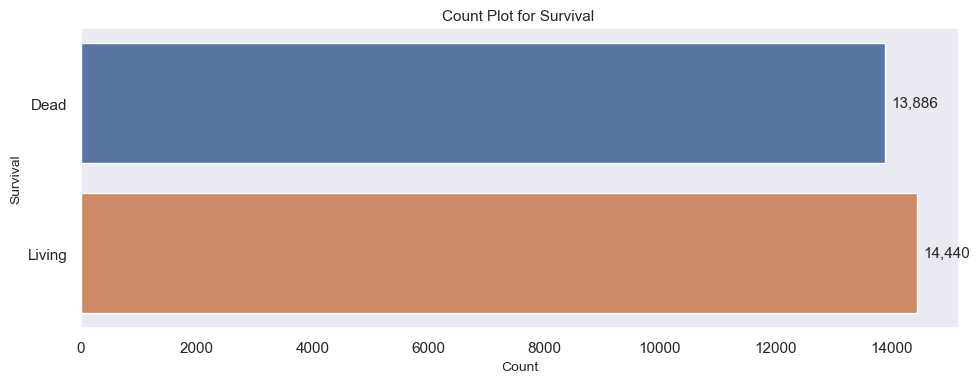

In [6]:
# create 'Survival' column using .loc[]
df.loc[:, 'Survival'] = np.where(pd.isna(df['TransplantSurvivalDay']), np.nan, df['TransplantSurvivalDay'] >= 1095)

# map boolean values to descriptive labels
df['Survival'] = df['Survival'].map({1: 'Living', 0: 'Dead'}, na_action='ignore')

# plot
uv.plot_count(df, ['Survival'], fig_size=(10, 4))

In [7]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  227

Boolean feature count: 0
Category feature count: 79
Numeric feature count: 45
Object feature count: 103
Other feature count: 0

Total feature count:  227


###  Display NaNs

In [8]:
# check for NaNs
missing_by_col, missing_by_row = uf.display_missing_values(df,top=20)

Columns that contain missing values (top 20 by count):
                            column_name  missing_count  missing_pct
0             Hemodynamics_Addition_CAN           5328    18.531529
1      HemodynamicsRegistration_PCW_CAN           2728     9.488366
2        HemodynamicsTransplant_PCW_CAN           2425     8.434489
3       HemodynamicsRegistration_CO_CAN           1659     5.770234
4         HemodynamicsTransplant_CO_CAN           1609     5.596327
5      HemodynamicsTransplant_PA_MN_CAN           1431     4.977218
6    HemodynamicsRegistration_PA_MN_CAN           1325     4.608535
7     HemodynamicsTransplant_PA_DIA_CAN           1169     4.065946
8        HemodynamicsTransplant_SYS_CAN           1149     3.996383
9   HemodynamicsRegistration_PA_DIA_CAN           1059     3.683350
10     HemodynamicsRegistration_SYS_CAN           1038     3.610309
11                         LengthOfStay            911     3.168585
12                 IschemicTimeHour_DON            564     1.

### Discretization / Remove Features

#### User Function(s)

In [9]:
def discretization(feature, newFeature, qcut, labelTxt):
    # use quartile bin
    _, bins = pd.qcut(df[feature].dropna(), q=qcut, retbins=True, precision=0)
    
    # create custom labels
    labels = [f'{labelTxt}({int(bins[i])}-{int(bins[i+1])})' for i in range(len(bins)-1)]
    
    # create the categorical column, initially with NaN for missing values
    df[newFeature] = pd.cut(df[feature], bins=bins, labels=labels, include_lowest=True)
    
    # replace NaN with 'Unknown'
    df[newFeature] = df[newFeature].cat.add_categories('Unknown').fillna('Unknown')

    return newFeature

#### Test of Independence for Categorical Variables
- Null Hypothesis (H0): The two variables are not related.
- Alternative Hypothesis (H1): The two variables are related.
- A low p-value (typically < 0.05) indicates a significant relationship between the variables.
- This is the Chi-Square test statistic. It measures the discrepancy between the observed and expected frequencies under the assumption that the variables are independent.
    - A larger `chi2` value indicates a greater difference between observed and expected counts, suggesting that the variables are more likely to be associated.
    - A small p_value (typically < 0.05) suggests that you can reject the null hypothesis and conclude that there is a significant association between the two variables.

#### Cramer's V values can be interpreted as:
- Cramer's V is a measure of association between two nominal (categorical) variables, based on the Chi-Square statistic and varies from `0` (corresponding to no association between the variables) to `1` (complete association) and can reach 1 only when each variable is completely determined by the other.
    - 0.00 to 0.10: Negligible association
    - 0.10 to 0.30: Weak association
    - 0.30 to 0.50: Moderate association
    - 0.50 to 0.70: Strong association
    - 0.70 to 1.00: Very strong association

#### Numeric

In [10]:
print(sorted(df_numeric.column.to_list()))

['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'Age_Mean_CAN', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'Hemodynamics_Addition_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'LengthOfStay', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'Level_SGOT_Addition_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalBilirubi

##### Age

In [11]:
features = uf.get_feature_list(df, 'Age_')

                   count        mean        std   min    25%    50%    75%    max
Age_Addition     28751.0  138.337310  29.437099  40.0  122.0  143.0  159.0  212.0
Age_CAN          28751.0   53.411429  12.860902  18.0   46.0   56.0   63.0   79.0
Age_DON          28751.0   32.122883  10.963701   8.0   23.0   31.0   40.0   72.0
Age_Listing_CAN  28751.0   52.802998  12.906853  12.0   46.0   56.0   63.0   78.0
Age_Mean_CAN     28751.0   53.107214  12.872387  15.0   46.0   56.0   63.0   78.5

:::: NaN Count:
Age_Addition       0
Age_CAN            0
Age_DON            0
Age_Listing_CAN    0
Age_Mean_CAN       0


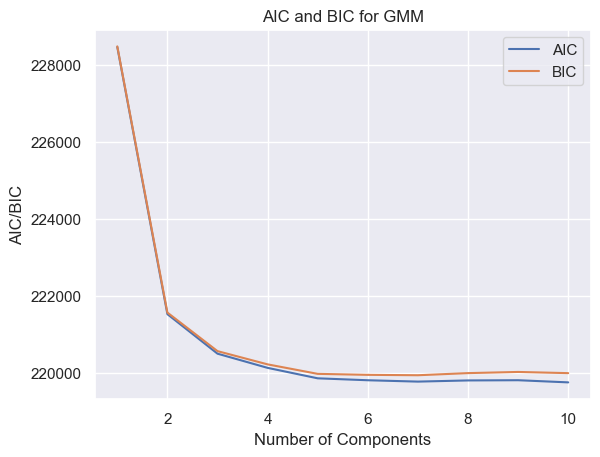

In [12]:
uif.gaussian_mixture_binning(df, ['Age_CAN'], RANDOM_STATE)

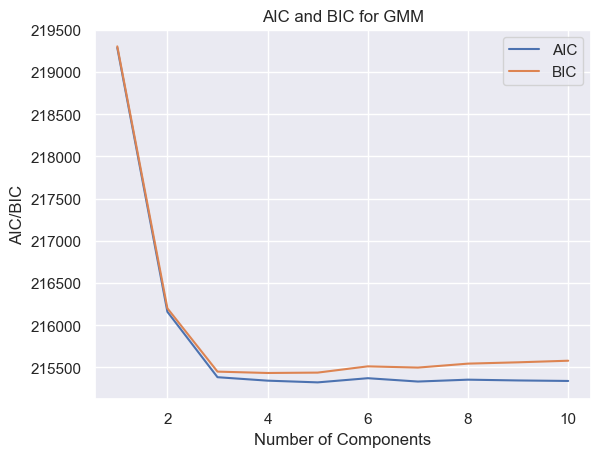

In [13]:
uif.gaussian_mixture_binning(df, ['Age_DON'], RANDOM_STATE)

In [14]:
# new category feature
newCol = discretization('Age_CAN', 'Age_CAT_CAN', 4, 'Age')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_can = uf.insert_into_dataframe(df_can, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Age(18-46),3561.0,3580.0,7141.0,49.866965,50.133035
Age(46-56),3354.0,3714.0,7068.0,47.453311,52.546689
Age(56-63),3528.0,3735.0,7263.0,48.574969,51.425031
Age(63-79),3443.0,3411.0,6854.0,50.233440,49.766560
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [15]:
# new category feature
newCol = discretization('Age_DON', 'Age_CAT_DON', 3, 'Age')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_don = uf.insert_into_dataframe(df_don, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Age(8-26),4620.0,5750.0,10370.0,44.551591,55.448409
Age(26-36),4536.0,3979.0,8515.0,53.270699,46.729301
Age(36-72),4730.0,4711.0,9441.0,50.100625,49.899375
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [16]:
# removeCols
removeCols = (features)

##### [BMI](https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html)
- The standard BMI ranges for adults are:
    - Underweight: BMI less than 18.5 kg/m²
    - Normal weight: BMI 18.5 to 24.9 kg/m²
    - Overweight: BMI 25 to 29.9 kg/m²
    - Obesity: BMI 30 kg/m² or greater
    - BMI = Weight (kg) / Height (m)²

In [17]:
def categorizeBMI(value):
    """
    Define the function for mapping
    """
    if value < 18.5:
        return "Under Weight"
    elif 18.5 <= value <= 24.9:
        return "Normal Weight"        
    elif 24.9 <= value <= 29.9:
        return "Over Weight"
    elif value >= 29.9:
        return "Obesity"
    else:
        return "Unknown"

##### HeightCm

In [18]:
features = uf.get_feature_list(df, 'HeightCm')

                     count        mean        std    min    25%    50%    75%    max
HeightCm_Addition  28751.0  347.642931  17.045463  239.0  335.5  348.7  360.6  404.1
HeightCm_CAN       28751.0  173.697270  10.031508  124.0  167.6  175.0  180.3  213.4
HeightCm_DON       28751.0  173.945661   9.576501  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_Addition    0
HeightCm_CAN         0
HeightCm_DON         0


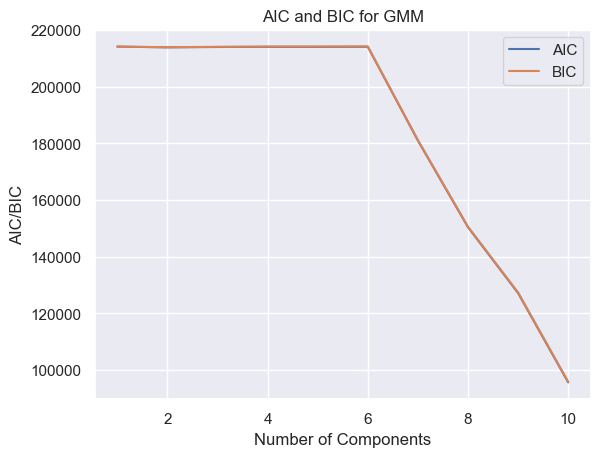

In [19]:
uif.gaussian_mixture_binning(df, ['HeightCm_CAN'], RANDOM_STATE)

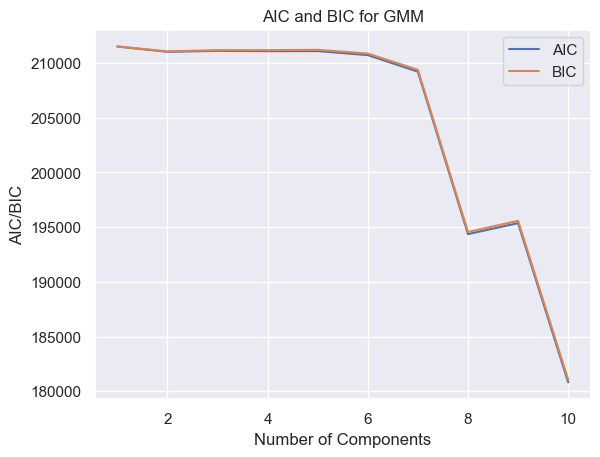

In [20]:
uif.gaussian_mixture_binning(df, ['HeightCm_DON'], RANDOM_STATE)

In [21]:
# new category feature
newCol = discretization('HeightCm_CAN', 'HeightCm_CAT_CAN', 4, 'HeightCm')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_can = uf.insert_into_dataframe(df_can, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm(124-167),4348.0,4292.0,8640.0,50.324074,49.675926
HeightCm(167-175),2633.0,2907.0,5540.0,47.527076,52.472924
HeightCm(175-180),3650.0,3879.0,7529.0,48.479214,51.520786
HeightCm(180-213),3255.0,3362.0,6617.0,49.191476,50.808524
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [22]:
# new category feature
newCol = discretization('HeightCm_DON', 'HeightCm_CAT_DON', 4, 'HeightCm')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_don = uf.insert_into_dataframe(df_don, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm(115-167),3482.0,3839.0,7321.0,47.561808,52.438192
HeightCm(167-175),3927.0,3843.0,7770.0,50.540541,49.459459
HeightCm(175-180),3107.0,3275.0,6382.0,48.683798,51.316202
HeightCm(180-213),3370.0,3483.0,6853.0,49.175544,50.824456
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [23]:
# removeCols
removeCols.extend(features)

##### WeightKg

In [24]:
features = uf.get_feature_list(df, 'WeightKg')

                     count        mean        std   min    25%    50%    75%    max
WeightKg_Addition  28740.0  166.972937  32.352999  72.2  144.2  165.0  187.4  335.6
WeightKg_CAN       28744.0   83.404634  18.115061  29.9   70.4   82.6   95.7  165.1
WeightKg_DON       28747.0   83.561332  19.553094  23.2   70.0   80.8   94.1  198.0

:::: NaN Count:
WeightKg_Addition    11
WeightKg_CAN          7
WeightKg_DON          4


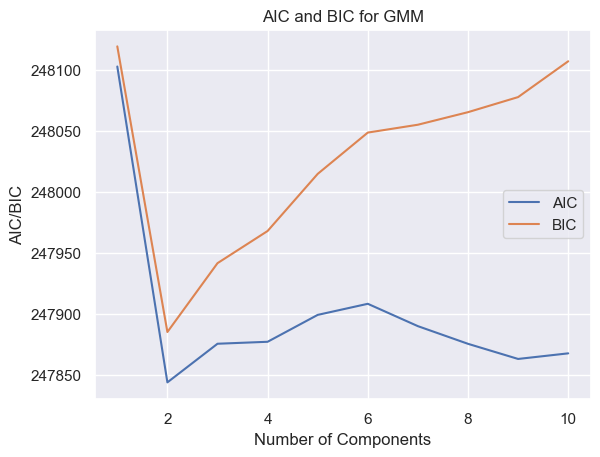

In [25]:
uif.gaussian_mixture_binning(df, ['WeightKg_CAN'], RANDOM_STATE)

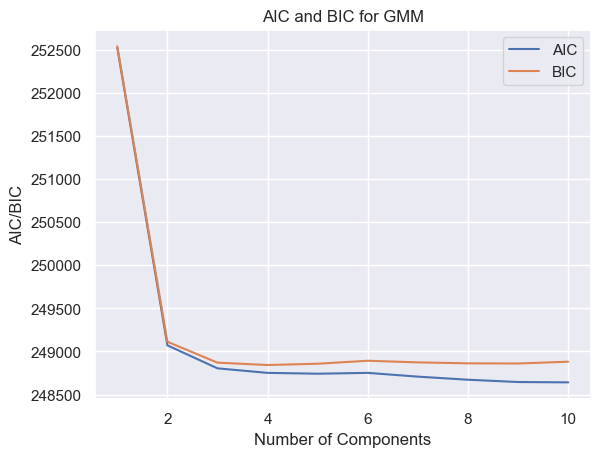

In [26]:
uif.gaussian_mixture_binning(df, ['WeightKg_DON'], RANDOM_STATE)

In [27]:
# new category feature
newCol = discretization('WeightKg_CAN', 'WeightKg_CAT_CAN', 2, 'WeightKg')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_can = uf.insert_into_dataframe(df_can, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg(29-82),6857.0,7442.0,14299.0,47.954402,52.045598
WeightKg(82-165),7026.0,6994.0,14020.0,50.114123,49.885877
Unknown,3.0,4.0,7.0,42.857143,57.142857
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [28]:
# new category feature
newCol = discretization('WeightKg_DON', 'WeightKg_CAT_DON', 3, 'WeightKg')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_don = uf.insert_into_dataframe(df_don, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg(23-73),4478.0,5020.0,9498.0,47.146768,52.853232
WeightKg(73-89),4633.0,4834.0,9467.0,48.938418,51.061582
WeightKg(89-198),4774.0,4584.0,9358.0,51.015174,48.984826
Unknown,1.0,2.0,3.0,33.333333,66.666667
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [29]:
# removeCols
removeCols.extend(features)

##### BMI

In [30]:
features = uf.get_feature_list(df, 'BMI_')

                count       mean       std        min        25%        50%        75%         max
BMI_Addition  28740.0  55.107232  8.731148  31.955650  48.856016  54.357372  60.458068  110.372240
BMI_CAN       28744.0  27.504985  4.875902  14.005023  23.901315  27.267401  31.007741   48.683517
BMI_DON       28747.0  27.600755  6.066491  13.128277  23.384354  26.553778  30.679328   74.321284

:::: NaN Count:
BMI_Addition    11
BMI_CAN          7
BMI_DON          4


In [31]:
# removeCols
removeCols.extend(features)
# create New feature
df['BMI_CAT_CAN'] = df['BMI_CAN'].apply(categorizeBMI)
df['BMI_CAT_DON'] = df['BMI_DON'].apply(categorizeBMI)

# category datatype
df['BMI_CAT_CAN'] = df['BMI_CAT_CAN'].astype('category')
df['BMI_CAT_DON'] = df['BMI_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['BMI_CAT_CAN', 'BMI_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['BMI_CAT_DON'])
df_can = uf.insert_into_dataframe(df_can, ['BMI_CAT_CAN'])

In [32]:
uf.category_contingency_survival(df, 'BMI_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,3987.0,4562.0,8549.0,46.637034,53.362966
Obesity,4654.0,4313.0,8967.0,51.901416,48.098584
Over Weight,4967.0,5247.0,10214.0,48.629332,51.370668
Under Weight,275.0,314.0,589.0,46.689304,53.310696
Unknown,3.0,4.0,7.0,42.857143,57.142857
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [33]:
uf.category_contingency_survival(df, 'BMI_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,4748.0,5233.0,9981.0,47.570384,52.429616
Obesity,4137.0,3933.0,8070.0,51.263941,48.736059
Over Weight,4747.0,5005.0,9752.0,48.677194,51.322806
Under Weight,253.0,267.0,520.0,48.653846,51.346154
Unknown,1.0,2.0,3.0,33.333333,66.666667
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [BloodPH](https://www.ncbi.nlm.nih.gov/books/NBK507807/)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [34]:
def categorizePH(value):
    """
    Define the function for mapping
    """
    if value < 7.35:
        return "Acidic"
    elif value > 7.45:
        return "Alkaline"        
    elif 7.35 <= value <= 7.45:
        return "Normal"
    else:
        return "Unknown"

In [35]:
features = uf.get_feature_list(df, 'BloodPH')

               count   mean       std  min   25%   50%   75%   max
BloodPH_DON  28521.0  7.416  0.073821  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    230


In [36]:
# create New feature
df['BloodPH_CAT_DON'] = df['BloodPH_DON'].apply(categorizePH)

# category datatype
df['BloodPH_CAT_DON'] = df['BloodPH_CAT_DON'].astype('category')

# update DataFrame
df_nominal = uf.insert_into_dataframe(df_nominal, ['BloodPH_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['BloodPH_CAT_DON'])

# add to list
removeCols.extend(features)

In [37]:
uf.category_contingency_survival(df, 'BloodPH_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Acidic,1646.0,1874.0,3520.0,46.761364,53.238636
Alkaline,3901.0,3824.0,7725.0,50.498382,49.501618
Normal,8286.0,8719.0,17005.0,48.726845,51.273155
Unknown,53.0,23.0,76.0,69.736842,30.263158
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [BloodUreaNitrogenLevel](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source report a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [38]:
def categorizeBUN(value, gender):
    """
    Define the function for mapping Blood Urea Nitrogen levels based on value and gender.
    """
    if (0.8 <= value <= 24 and gender == 'M') or (6 <= value <= 21 and gender == 'F'):
        return 'Normal'
    elif (value < 0.8 and gender == 'M') or (value < 6 and gender == 'F'):
        return "Low"
    elif (value > 24 and gender == 'M') or (value > 21 and gender == 'F'):
        return "High"
    else:
        return "Unknown"

In [39]:
features = uf.get_feature_list(df, 'BloodUreaNitrogenLevel_DON')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  28546.0  23.991873  19.930901  0.5  12.0  18.0  28.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    205


In [40]:
# create new feature
df['BloodUreaNitrogenLevel_CAT_DON'] = df.apply(lambda row: categorizeBUN(row['BloodUreaNitrogenLevel_DON'], row['Gender_DON']), axis=1)

# category datatype
df['BloodUreaNitrogenLevel_CAT_DON'] = df['BloodUreaNitrogenLevel_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['BloodUreaNitrogenLevel_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['BloodUreaNitrogenLevel_CAT_DON'])

# add to list
removeCols.extend(features)

In [41]:
uf.category_contingency_survival(df, 'BloodUreaNitrogenLevel_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,5540.0,3938.0,9478.0,58.451150,41.548850
Low,123.0,233.0,356.0,34.550562,65.449438
Normal,8188.0,10252.0,18440.0,44.403471,55.596529
Unknown,35.0,17.0,52.0,67.307692,32.692308
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
- Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    - Normal
        - 0.7 to 1.3 mg/dL for adult males
        - 0.5 to 1.1 mg/dL for adult females
- High creatinine levels can indicate kidney dysfunction, dehydration, or other conditions affecting the kidneys. If you have concerns about your creatinine levels, it's best to consult with a healthcare professional for proper evaluation and guidance.

In [42]:
def categorizeCR(value, gender):
    """
    Define the function for mapping creatinine levels based on value and gender.
    """
    if (0.7 <= value <= 1.3 and gender == 'M') or (0.5 <= value <= 1.1 and gender == 'F'):
        return 'Normal'
    elif (value < 0.7 and gender == 'M') or (value < 0.5 and gender == 'F'):
        return "Low"
    elif (value > 1.3 and gender == 'M') or (value > 1.1 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [43]:
features = uf.get_feature_list(df, 'Creatinine')

                              count      mean       std   min   25%  50%   75%   max
CreatinineRegistration_CAN  28604.0  1.363390  0.959501  0.08  0.94  1.2  1.50  24.0
CreatinineTransplant_CAN    28330.0  1.372100  1.001949  0.06  0.94  1.2  1.50  37.0
Creatinine_Addition         28192.0  4.229285  2.326355  0.91  2.98  3.6  4.61  50.3
Creatinine_DON              28546.0  1.496195  1.543989  0.04  0.76  1.0  1.48  23.0

:::: NaN Count:
CreatinineRegistration_CAN    147
CreatinineTransplant_CAN      421
Creatinine_Addition           559
Creatinine_DON                205


In [44]:
df[features].corr()

,CreatinineRegistration_CAN,CreatinineTransplant_CAN,Creatinine_Addition,Creatinine_DON
CreatinineRegistration_CAN,1.000000,0.672968,0.677739,-0.036554
CreatinineTransplant_CAN,0.672968,1.000000,0.693022,-0.023086
Creatinine_Addition,0.677739,0.693022,1.000000,0.637372
Creatinine_DON,-0.036554,-0.023086,0.637372,1.000000


In [45]:
df.groupby('Gender_DON', observed=False)['Creatinine_DON'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_DON,,,,,,,,
F,8357.0,1.286049,1.323137,0.04,0.62,0.81,1.29,15.0
M,20189.0,1.583183,1.618723,0.05,0.80,1.07,1.51,23.0


In [46]:
df.groupby('Gender_CAN', observed=False)['CreatinineRegistration_CAN'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_CAN,,,,,,,,
F,7666.0,1.187523,0.894605,0.19,0.8,1.00,1.30,21.0
M,20938.0,1.427780,0.974303,0.08,1.0,1.22,1.54,24.0


In [47]:
df.groupby('Gender_CAN', observed=False)['CreatinineTransplant_CAN'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_CAN,,,,,,,,
F,7592.0,1.199481,0.992485,0.13,0.8,1.00,1.30,24.0
M,20738.0,1.435294,0.997976,0.06,1.0,1.24,1.57,37.0


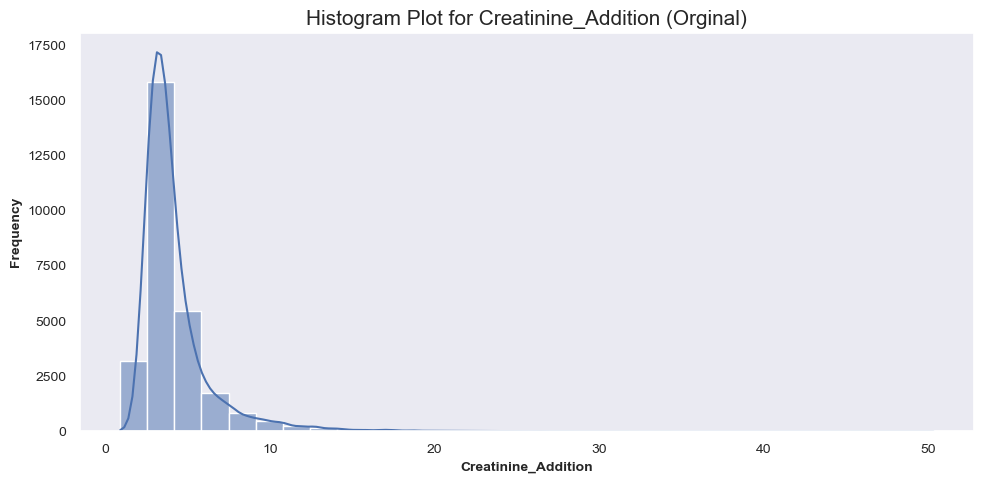

In [48]:
# plot
uv.plot_histogram(df, ['Creatinine_Addition'], txt='(Orginal)', bins=30)

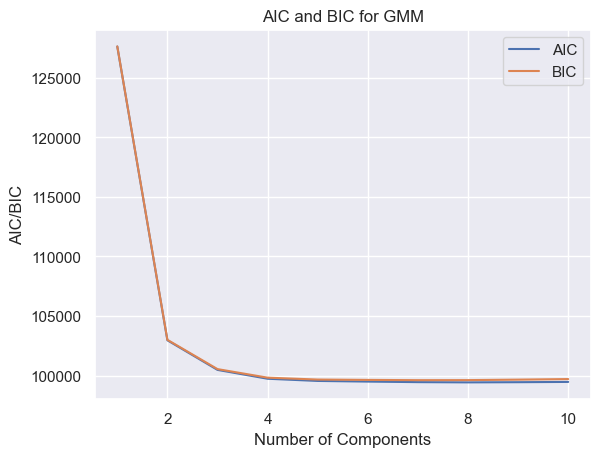

In [49]:
uif.gaussian_mixture_binning(df, ['Creatinine_Addition'], RANDOM_STATE)

In [50]:
# removeCols
removeCols.extend(features)
# new category feature
newCol = discretization('Creatinine_Addition', 'Creatinine_Addition_CAT', 4, 'Creatinine Addition')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_both = uf.insert_into_dataframe(df_both, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Creatinine Addition(0-2),3238.0,3803.0,7041.0,45.987786,54.012214
Creatinine Addition(2-3),3236.0,3809.0,7045.0,45.933286,54.066714
Creatinine Addition(3-4),3435.0,3607.0,7042.0,48.778756,51.221244
Creatinine Addition(4-50),3859.0,3162.0,7021.0,54.963680,45.036320
Unknown,118.0,59.0,177.0,66.666667,33.333333
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [51]:
# create new feature
df['Creatinine_CAT_DON'] = df.apply(lambda row: categorizeCR(row['Creatinine_DON'], row['Gender_DON']), axis=1)
df['Creatinine_CAT_CAN'] = df.apply(lambda row: categorizeCR(row['CreatinineTransplant_CAN'], row['Gender_CAN']), axis=1)

# category datatype
df['Creatinine_CAT_DON'] = df['Creatinine_CAT_DON'].astype('category')
df['Creatinine_CAT_DON'] = df['Creatinine_CAT_DON'].astype('category')

# update dataframe
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Creatinine_CAT_CAN', 'Creatinine_CAT_DON'])
df_can = uf.insert_into_dataframe(df_can, ['Creatinine_CAT_CAN'])
df_don = uf.insert_into_dataframe(df_don, ['Creatinine_CAT_DON'])

In [52]:
uf.category_contingency_survival(df, 'Creatinine_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,5937.0,5765.0,11702.0,50.734917,49.265083
Low,349.0,277.0,626.0,55.750799,44.249201
Normal,7548.0,8395.0,15943.0,47.343662,52.656338
Unknown,52.0,3.0,55.0,94.545455,5.454545
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [53]:
uf.category_contingency_survival(df, 'Creatinine_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,4679.0,4210.0,8889.0,52.638092,47.361908
Low,1461.0,1325.0,2786.0,52.440775,47.559225
Normal,7711.0,8888.0,16599.0,46.454606,53.545394
Unknown,35.0,17.0,52.0,67.307692,32.692308
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### DistanceFromDonorHospitaltoTXCenter

In [54]:
features = uf.get_feature_list(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  28751.0  200.200097  221.177082  0.0  20.0  126.0  321.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


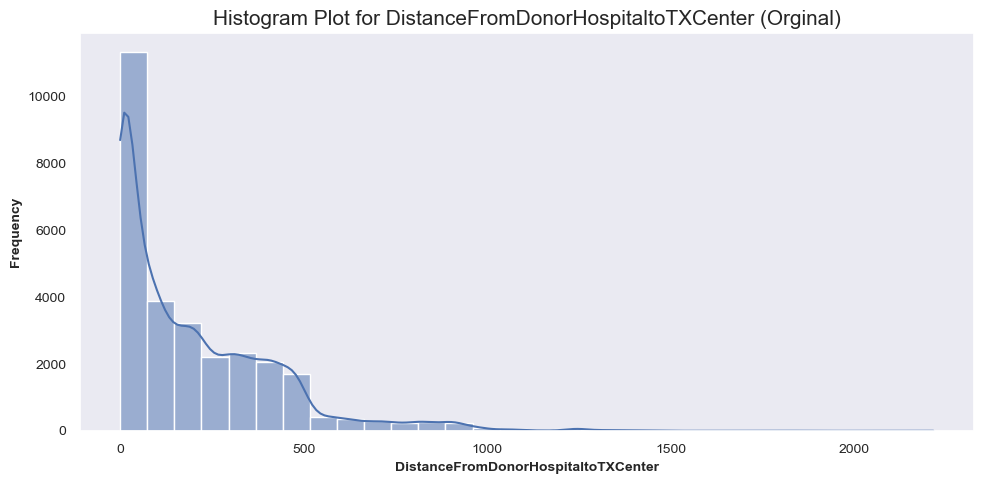

In [55]:
# plot
uv.plot_histogram(df, features, txt='(Orginal)', bins=30)

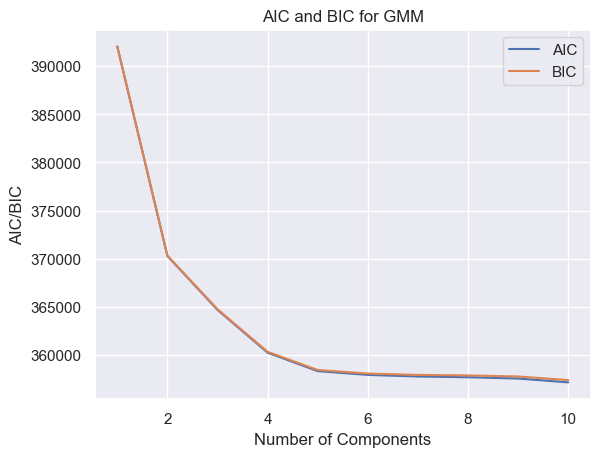

In [56]:
uif.gaussian_mixture_binning(df, ['DistanceFromDonorHospitaltoTXCenter'], RANDOM_STATE)

In [57]:
# add to list
removeCols.extend(features)
# new category feature
newCol = discretization('DistanceFromDonorHospitaltoTXCenter', 'DistanceFromDonorHospitaltoTXCenter_CAT', 5, 'Distance Miles')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_both = uf.insert_into_dataframe(df_both, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Distance Miles(0-12),2023.0,3835.0,5858.0,34.533971,65.466029
Distance Miles(12-77),2263.0,3316.0,5579.0,40.562825,59.437175
Distance Miles(77-198),2906.0,2803.0,5709.0,50.902084,49.097916
Distance Miles(198-371),3307.0,2284.0,5591.0,59.148632,40.851368
Distance Miles(371-2215),3387.0,2202.0,5589.0,60.601181,39.398819
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [Hematocrit_DON](https://www.mountsinai.org/health-library/tests/hematocrit)
- Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

In [58]:
def categorizeH(value, gender):
    """
    Define the function for mapping Hematocrit levels based on value and gender.
    """
    if (40.7 <= value <= 50.3 and gender == 'M') or (36.1 <= value <= 44.3 and gender == 'F'):
        return 'Normal'
    elif (value < 40.7 and gender == 'M') or (value < 36.1 and gender == 'F'):
        return "Low"
    elif (value > 50.3 and gender == 'M') or (value > 44.3 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [59]:
features = uf.get_feature_list(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  28546.0  28.433506  5.001157  2.3  25.0  28.0  31.3  75.0

:::: NaN Count:
Hematocrit_DON    205


In [60]:
# create new feature
df['Hematocrit_CAT_DON'] = df.apply(lambda row: categorizeH(row['Hematocrit_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Hematocrit_CAT_DON'] = df['Hematocrit_CAT_DON'].astype('category')

# update dataframe
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Hematocrit_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['Hematocrit_CAT_DON'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Hematocrit_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,15.0,22.0,37.0,40.540541,59.459459
Low,13549.0,13956.0,27505.0,49.260135,50.739865
Normal,287.0,445.0,732.0,39.207650,60.792350
Unknown,35.0,17.0,52.0,67.307692,32.692308
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Hemodynamics
- [CO (Cardiac Output)](https://www.ncbi.nlm.nih.gov/books/NBK470455/#:~:text=Cardiac%20output%20in%20humans%20is,to%20100%20times%20each%20minute.):
    - Definition: Similar to the registration phase, it measures the heart's output during the transplant phase.
    - Importance: Critical for ensuring adequate perfusion during surgery.
    - Cardiac output in humans is generally 5-6 L/min
- [PA_DIA (Pulmonary Artery Diastolic Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Monitored to assess right heart function and pulmonary circulation during transplant.
- [PA_MN (Pulmonary Artery Mean Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Helps in evaluating pulmonary hypertension and right ventricular function.
    - Severe pulmonary hypertension artery pressure of 40 mm Hg or greater
    - Moderate pulmonary hypertension artery pressure between 25 and 39 mm Hg
    - Normal pulmonary artery pressure between 11 and 25 mm Hg
- [PCW (Pulmonary Capillary Wedge Pressure)](https://pubmed.ncbi.nlm.nih.gov/24268673/):
    - Definition: Used to monitor left ventricular function and fluid status during transplant.
- [SYS (Systemic Arterial Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK538509/):
    - Definition: Monitored to ensure stable blood pressure and perfusion during transplant.

In [61]:
def categorizeCO(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 5:
        return "Low"
    elif value > 6:
        return "High"    
    if 5 <= value <= 6:
        return "Normal"
    else:
        return "Unknown"

def categorizePA(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 11:
        return 'Low'
    elif 11 <= value <= 25:
        return "Normal"
    elif 25 <= value <= 40:
        return "High"
    elif value >= 40:
        return "Extreme"
    else:
        return "Unknown"

In [62]:
features = uf.get_feature_list(df, 'HemodynamicsR|HemodynamicsT')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      27092.0   4.266872   1.345663  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  27692.0  20.529113   8.688313  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   27426.0  28.657685  10.213014  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     26023.0  19.142739   8.802624  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     27713.0  42.056400  14.254475  0.00  31.00  41.00  52.00  130.0
HemodynamicsTransplant_CO_CAN        27142.0   4.537917   1.457784  0.20   3.51   4.40   5.36   15.0
HemodynamicsTransplant_PA_DIA_CAN    27582.0  19.144776   8.476800  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     27320.0  27.004952   9.922125  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       26326.0  17.764157   8.676076  0.00  11.00  17.00  24.

In [63]:
df[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.212275,-0.188223,-0.233193,-0.148357,0.508997,-0.099349,-0.084288,-0.104403,-0.065083
HemodynamicsRegistration_PA_DIA_CAN,-0.212275,1.000000,0.893479,0.823933,0.786575,-0.069231,0.519014,0.504899,0.456370,0.455086
HemodynamicsRegistration_PA_MN_CAN,-0.188223,0.893479,1.000000,0.837968,0.918693,-0.049440,0.495646,0.550640,0.462904,0.529963
HemodynamicsRegistration_PCW_CAN,-0.233193,0.823933,0.837968,1.000000,0.763577,-0.075012,0.464893,0.484381,0.543227,0.446195
HemodynamicsRegistration_SYS_CAN,-0.148357,0.786575,0.918693,0.763577,1.000000,-0.031109,0.448326,0.530518,0.424563,0.573206
HemodynamicsTransplant_CO_CAN,0.508997,-0.069231,-0.049440,-0.075012,-0.031109,1.000000,-0.218352,-0.186911,-0.221604,-0.156447
HemodynamicsTransplant_PA_DIA_CAN,-0.099349,0.519014,0.495646,0.464893,0.448326,-0.218352,1.000000,0.901245,0.820000,0.791405
HemodynamicsTransplant_PA_MN_CAN,-0.084288,0.504899,0.550640,0.484381,0.530518,-0.186911,0.901245,1.000000,0.832616,0.917218
HemodynamicsTransplant_PCW_CAN,-0.104403,0.456370,0.462904,0.543227,0.424563,-0.221604,0.820000,0.832616,1.000000,0.761240
HemodynamicsTransplant_SYS_CAN,-0.065083,0.455086,0.529963,0.446195,0.573206,-0.156447,0.791405,0.917218,0.761240,1.000000


##### Parameters related to pulmonary and systemic pressures (PA_DIA, PA_MN, PCW, SYS) are strongly positively correlated. This means that when one of these pressures increases, the others will also increase; therefore, use PA_MN ONLY.

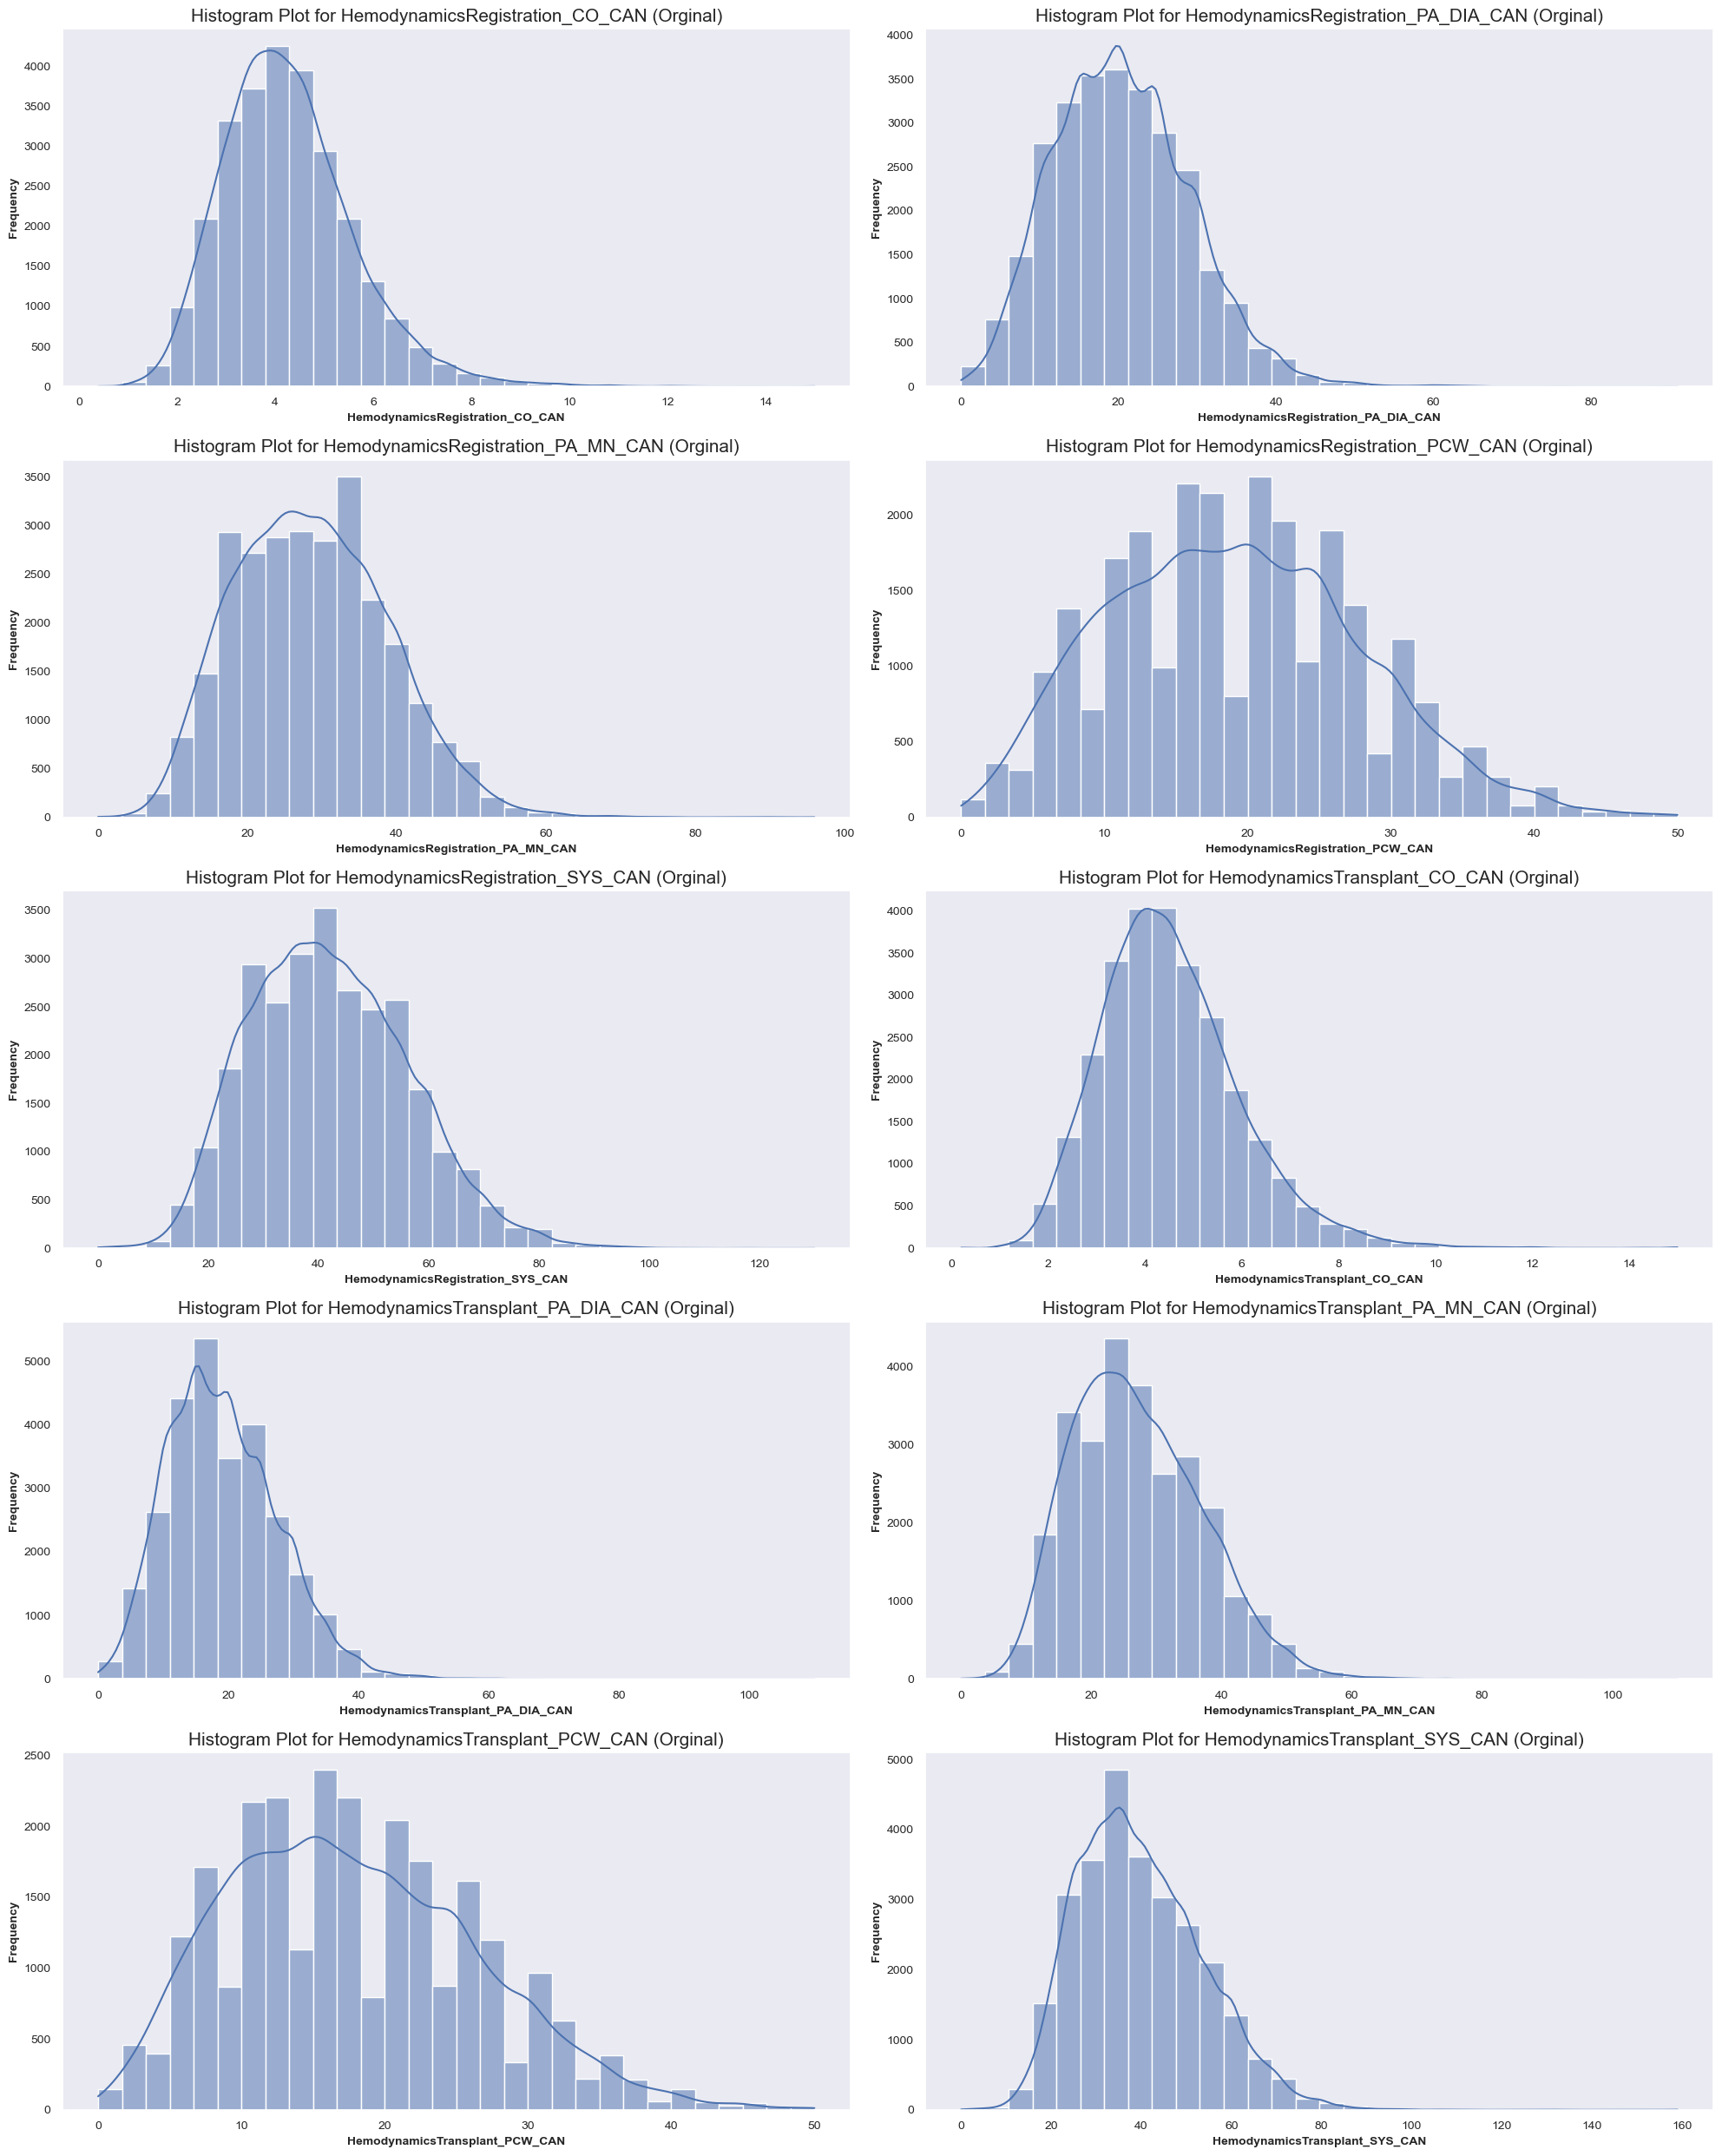

In [64]:
# plot
uv.plot_histogram(df, features, txt='(Orginal)', bins=30)

In [65]:
# add to list
removeCols.extend(features)

# create New feature
df['HemodynamicsRegistration_PA_MN_CAT_CAN'] = df['HemodynamicsRegistration_PA_MN_CAN'].apply(categorizePA)
df['HemodynamicsTransplant_PA_MN_CAT_CAN'] = df['HemodynamicsTransplant_PA_MN_CAN'].apply(categorizePA)
df['HemodynamicsRegistration_CO_CAT_CAN'] = df['HemodynamicsRegistration_CO_CAN'].apply(categorizeCO)
df['HemodynamicsTransplant_CO_CAT_CAN'] = df['HemodynamicsTransplant_CO_CAN'].apply(categorizeCO)

# initialize
newCols = ['HemodynamicsRegistration_PA_MN_CAT_CAN','HemodynamicsTransplant_PA_MN_CAT_CAN','HemodynamicsRegistration_CO_CAT_CAN','HemodynamicsTransplant_CO_CAT_CAN']

# category datatype
uf.convert_to_category(df, newCols)

# update dataframe
df_ordinal = uf.insert_into_dataframe(df_ordinal, newCols)
df_can = uf.insert_into_dataframe(df_can, newCols)

In [66]:
# display
for feature in newCols:
    print(uf.category_contingency_survival(df, feature).to_string(), feature)
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Extreme        1659.0   1763.0     3422.0  48.480421  51.519579
High           6065.0   6606.0    12671.0  47.865204  52.134796
Low             263.0    227.0      490.0  53.673469  46.326531
Normal         5276.0   5203.0    10479.0  50.348316  49.651684
Unknown         623.0    641.0     1264.0  49.287975  50.712025
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900 HemodynamicsRegistration_PA_MN_CAT_CAN


Survival         Dead   Living  Row Total     Dead %   Living %
Extreme        1359.0   1283.0     2642.0  51.438304  48.561696
High           5586.0   5827.0    11413.0  48.944186  51.055814
Low             267.0    288.0      555.0  48.108108  51.891892
Normal         6054.0   6598.0    12652.0  47.850142  52.149858
Unknown         620.0    444.0     1064.0  58.270677  41.729323
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900 HemodynamicsTransplant_PA_MN_CAT_CAN


Survival         Dead   

In [67]:
features = uf.get_feature_list(df, 'Hemodynamics_Addition')

                             count        mean        std    min      25%     50%    75%    max
Hemodynamics_Addition_CAN  23423.0  222.520626  68.581583  37.68  172.145  220.44  268.9  532.5

:::: NaN Count:
Hemodynamics_Addition_CAN    5328


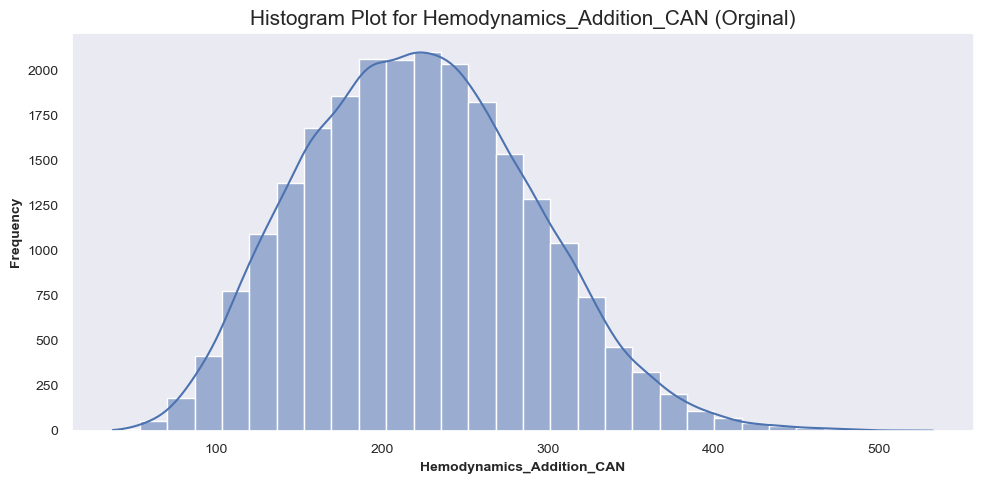

In [68]:
# plot
uv.plot_histogram(df, features, txt='(Orginal)', bins=30)

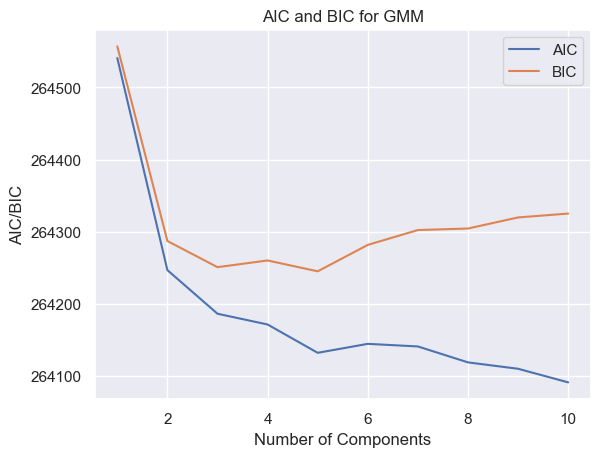

In [69]:
uif.gaussian_mixture_binning(df,features, RANDOM_STATE)

In [70]:
# removeCols
removeCols.extend(features)

# new category feature
newCol = discretization('Hemodynamics_Addition_CAN', 'Hemodynamics_Addition_CAT_CAN', 3, 'Hemodynamics Addition')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_can = uf.insert_into_dataframe(df_can, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Hemodynamics Addition(37-189),3890.0,3901.0,7791.0,49.929406,50.070594
Hemodynamics Addition(189-251),3629.0,4168.0,7797.0,46.543542,53.456458
Hemodynamics Addition(251-532),3849.0,3942.0,7791.0,49.403157,50.596843
Unknown,2518.0,2429.0,4947.0,50.899535,49.100465
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without blood supply before significant damage occurs, is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [71]:
def categoryISC(value):
    if value <= 2.6:
        return 'Low'
    elif 2.6 <= value <= 4:
        return 'Normal'
    elif value > 4:
        return 'High'
    else:
        return 'Unknown'

In [72]:
features = uf.get_feature_list(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  28187.0  3.233434  1.070273  0.3  2.5  3.3  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    564


In [73]:
# create New feature
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_DON'].apply(categoryISC)
# category datatype
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_CAT'].astype('category')

# update dataframe
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['IschemicTimeHour_CAT'])
df_both = uf.insert_into_dataframe(df_both, ['IschemicTimeHour_CAT'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'IschemicTimeHour_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2958.0,2300.0,5258.0,56.257132,43.742868
Low,3255.0,4965.0,8220.0,39.598540,60.401460
Normal,7551.0,7109.0,14660.0,51.507503,48.492497
Unknown,122.0,66.0,188.0,64.893617,35.106383
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [LV_EjectionFractionPercent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
- Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    - Male:
        - Nomal: 52% to 72%
        - Mildly Abnormal: 41% to 51%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 
    - Female:
        - Nomal: 54% to 74%
        - Mildly Abnormal: 41% to 53%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 

In [74]:
def categorizeLV(value, gender):
    """
    Define the function for mapping LV Ejection Fraction Percent based on value and gender.
    """
    if (52 <= value <= 72 and gender == 'M') or (54 <= value <= 74 and gender == 'F'):
        return 'Normal'
    elif (41 <= value <= 52 and gender == 'M') or (41 <= value <= 54 and gender == 'F'):
        return "Mildly Abnormal"
    elif (30 <= value <= 41) and gender in ['M', 'F']:
        return "Moderately Abnormal"
    elif (value < 30) and gender in ['M', 'F']:
        return "Severely Abnormal"
    elif (value > 72 and gender == 'M') or (value > 74 and gender == 'F'):
        return 'Below Normal'
    else:
        return "Unknown"

In [75]:
features = uf.get_feature_list(df, 'LV_EjectionFractionPercent_DON')

                                  count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  28718.0  61.618541  6.660556  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    33


In [76]:
# create new feature
df['LV_EjectionFractionPercent_CAT_DON'] = df.apply(lambda row: categorizeLV(row['LV_EjectionFractionPercent_DON'], row['Gender_DON']), axis=1)

# category datatype
df['LV_EjectionFractionPercent_CAT_DON'] = df['LV_EjectionFractionPercent_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['LV_EjectionFractionPercent_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['LV_EjectionFractionPercent_CAT_DON'])

# add to list
removeCols.extend(features)

In [77]:
df.groupby('Gender_DON', observed=False)['LV_EjectionFractionPercent_CAT_DON'].describe()

,count,unique,top,freq
Gender_DON,,,,
F,8406,6,Normal,7532
M,20345,6,Normal,18101


In [78]:
uf.category_contingency_survival(df, 'LV_EjectionFractionPercent_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Below Normal,664.0,740.0,1404.0,47.293447,52.706553
Mildly Abnormal,691.0,815.0,1506.0,45.883134,54.116866
Moderately Abnormal,57.0,53.0,110.0,51.818182,48.181818
Normal,12452.0,12810.0,25262.0,49.291426,50.708574
Severely Abnormal,11.0,2.0,13.0,84.615385,15.384615
Unknown,11.0,20.0,31.0,35.483871,64.516129
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Level_SGOT
- `SGOT`, also known as aspartate aminotransferase `(AST)`, is an enzyme primarily found in the liver, heart, kidneys, and muscles. It plays a crucial role in amino acid metabolism by catalyzing the transfer of an amino group from aspartate to α-ketoglutarate, producing oxaloacetate and glutamate.
    - Conservative normal range of 8 to 45 units/L for healthy individuals. 
- Alanine aminotransferase `(ALT)`, also known as serum glutamic-pyruvic transaminase `(SGPT)`, is an enzyme primarily found in the liver. It plays a crucial role in amino acid metabolism by catalyzing the conversion of alanine and α-ketoglutarate into pyruvate and glutamate. ALT is commonly measured in blood tests to evaluate liver function and detect liver damage.
    - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [79]:
def categoryAST(value):
    if value <= 8:
        return 'Low'
    elif 8 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'


def categoryALT(value):
    if value <= 7:
        return 'Low'
    elif 7 <= value <= 56:
        return 'Normal'
    elif value > 56:
        return 'High'
    else:
        return 'Unknown'

In [80]:
features = uf.get_feature_list(df, 'Level_SGOT')

                           count        mean         std  min   25%   50%    75%      max
Level_SGOT_ALT_DON       28541.0  114.102099  404.318823  3.0  23.0  41.0   83.0  44117.0
Level_SGOT_AST_DON       28541.0  101.952167  300.421156  0.3  26.0  44.0   87.0  10254.0
Level_SGOT_Addition_DON  28541.0  216.054266  624.686564  9.0  55.0  91.0  176.0  44267.0

:::: NaN Count:
Level_SGOT_ALT_DON         210
Level_SGOT_AST_DON         210
Level_SGOT_Addition_DON    210


In [81]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON,Level_SGOT_Addition_DON
Level_SGOT_ALT_DON,1.000000,0.561914,0.917467
Level_SGOT_AST_DON,0.561914,1.000000,0.844605
Level_SGOT_Addition_DON,0.917467,0.844605,1.000000


In [82]:
# create New feature
df['SGOT_ALT_CAT_DON'] = df['Level_SGOT_ALT_DON'].apply(categoryALT)
df['SGOT_AST_CAT_DON'] = df['Level_SGOT_AST_DON'].apply(categoryAST)
# category datatype
df['SGOT_ALT_CAT_DON'] = df['SGOT_ALT_CAT_DON'].astype('category')
df['SGOT_AST_CAT_DON'] = df['SGOT_AST_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['SGOT_ALT_CAT_DON', 'SGOT_AST_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['SGOT_ALT_CAT_DON', 'SGOT_AST_CAT_DON'])

In [83]:
uf.category_contingency_survival(df, 'SGOT_ALT_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,5331.0,5030.0,10361.0,51.452562,48.547438
Low,95.0,110.0,205.0,46.341463,53.658537
Normal,8424.0,9279.0,17703.0,47.585155,52.414845
Unknown,36.0,21.0,57.0,63.157895,36.842105
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [84]:
uf.category_contingency_survival(df, 'SGOT_AST_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,6743.0,7107.0,13850.0,48.685921,51.314079
Low,99.0,109.0,208.0,47.596154,52.403846
Normal,7008.0,7203.0,14211.0,49.313912,50.686088
Unknown,36.0,21.0,57.0,63.157895,36.842105
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [85]:
featuresD = uf.get_feature_list(df, 'Level_SGOT_Addition')

                           count        mean         std  min   25%   50%    75%      max
Level_SGOT_Addition_DON  28541.0  216.054266  624.686564  9.0  55.0  91.0  176.0  44267.0

:::: NaN Count:
Level_SGOT_Addition_DON    210


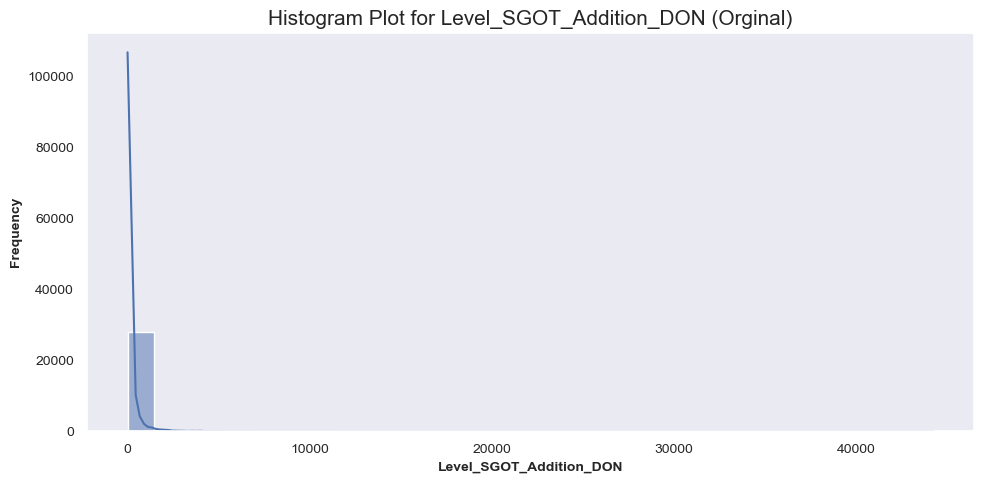

In [86]:
# plot
uv.plot_histogram(df, featuresD, txt='(Orginal)', bins=30)

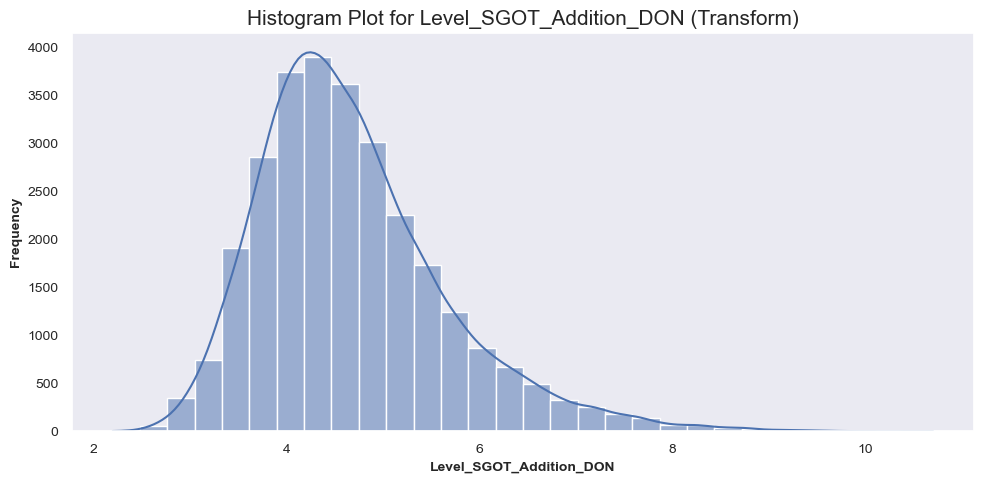

In [87]:
# transform
df[featuresD] = np.log(df[featuresD])
# plot
uv.plot_histogram(df, featuresD, txt='(Transform)', bins=30)

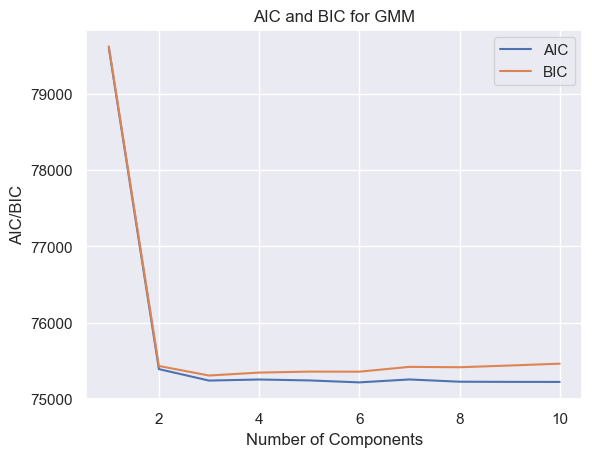

In [88]:
uif.gaussian_mixture_binning(df, featuresD, RANDOM_STATE)

In [89]:
# removeCols
removeCols.extend(features)
removeCols.extend(featuresD)
# new category feature
newCol = discretization('Level_SGOT_Addition_DON', 'Level_SGOT_Addition_CAT_DON', 2, 'SGOT Addition')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_don = uf.insert_into_dataframe(df_don, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
SGOT Addition(2-4),6771.0,7365.0,14136.0,47.898981,52.101019
SGOT Addition(4-10),7079.0,7054.0,14133.0,50.088445,49.911555
Unknown,36.0,21.0,57.0,63.157895,36.842105
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### [OrganRecovery_PCO2_DON](https://www.ncbi.nlm.nih.gov/books/NBK551648/)
- A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and C02 becomes impaired, the PC02 level may become increased. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
- The normal range for the partial pressure of carbon dioxide (pCO2) in arterial blood is typically between 35 to 45 mmHg

In [90]:
def categoryPCO2(value):
    if value < 35:
        return 'Low'
    elif 35 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'

In [91]:
features = uf.get_feature_list(df, 'OrganRecovery_PCO2_DON')

                          count       mean      std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  28515.0  38.617131  7.06791  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    236


In [92]:
# new feature
df['OrganRecovery_PCO2_CAT_DON'] = df.OrganRecovery_PCO2_DON.apply(categoryPCO2)

# category datatype
df['OrganRecovery_PCO2_CAT_DON'] = df['OrganRecovery_PCO2_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['OrganRecovery_PCO2_CAT_DON'])
df_don = uf.insert_into_dataframe(df_don, ['OrganRecovery_PCO2_CAT_DON'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'OrganRecovery_PCO2_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2097.0,1851.0,3948.0,53.115502,46.884498
Low,3539.0,4523.0,8062.0,43.897296,56.102704
Normal,8192.0,8042.0,16234.0,50.461993,49.538007
Unknown,58.0,24.0,82.0,70.731707,29.268293
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Bilirubin
- Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    - Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    - Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    - Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    - Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes. 

In [93]:
features = uf.get_feature_list(df, 'TotalBilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    28542.0  1.043629  1.424194  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  28289.0  0.993461  1.714805  0.1  0.5  0.7  1.1  80.0
TotalBilirubin_Addition       28220.0  2.036444  2.231294  0.3  1.1  1.6  2.2  80.3

:::: NaN Count:
TerminalTotalBilirubin_DON      209
TotalBilirubinTransplant_CAN    462
TotalBilirubin_Addition         531


In [94]:
def catMapB(value):
    if value <= 1.2:
        return 'Normal'
    elif value > 1.2:
        return 'High'
    else:
        return 'Unknown'

In [95]:
# new features
df['Bilirubin_CAT_CAN'] = df['TotalBilirubinTransplant_CAN'].map(catMapB).fillna(df['TotalBilirubinTransplant_CAN'])
df['Bilirubin_CAT_DON'] = df['TerminalTotalBilirubin_DON'].map(catMapB).fillna(df['TerminalTotalBilirubin_DON'])

# category datatype
df['Bilirubin_CAT_CAN'] = df['Bilirubin_CAT_CAN'].astype('category')
df['Bilirubin_CAT_DON'] = df['Bilirubin_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON'])
df_can = uf.insert_into_dataframe(df_can, ['Bilirubin_CAT_CAN'])
df_don = uf.insert_into_dataframe(df_don, ['Bilirubin_CAT_DON'])

In [96]:
uf.category_contingency_survival(df, 'Bilirubin_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2773.0,2560.0,5333.0,51.997000,48.003000
Normal,11047.0,11850.0,22897.0,48.246495,51.753505
Unknown,66.0,30.0,96.0,68.750000,31.250000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [97]:
uf.category_contingency_survival(df, 'Bilirubin_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2900.0,3141.0,6041.0,48.005297,51.994703
Normal,10950.0,11279.0,22229.0,49.259976,50.740024
Unknown,36.0,20.0,56.0,64.285714,35.714286
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [98]:
featuresD = uf.get_feature_list(df, 'TotalBilirubin_Addition')

                           count      mean       std  min  25%  50%  75%   max
TotalBilirubin_Addition  28220.0  2.036444  2.231294  0.3  1.1  1.6  2.2  80.3

:::: NaN Count:
TotalBilirubin_Addition    531


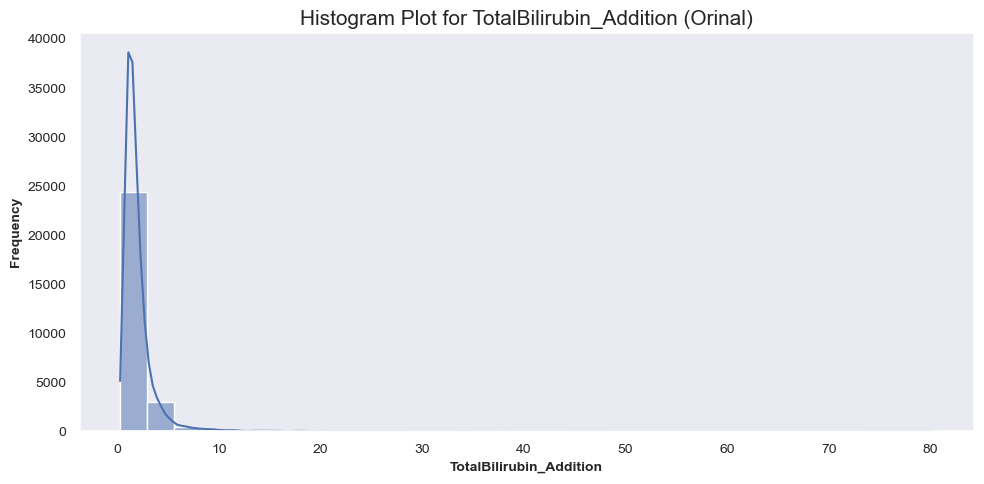

In [99]:
# plot
uv.plot_histogram(df, featuresD, txt='(Orinal)', bins=30)

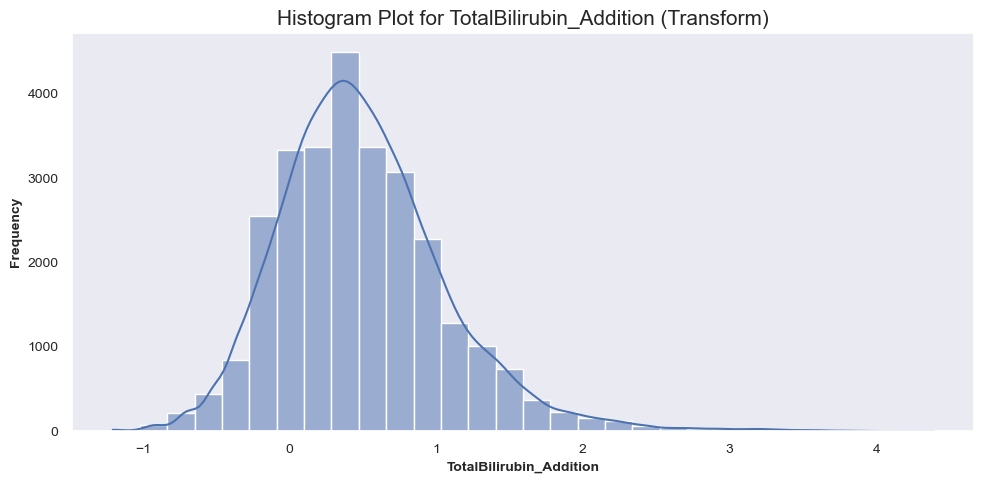

In [100]:
# transform
df[featuresD] = np.log(df[featuresD])
# plot
uv.plot_histogram(df, featuresD, txt='(Transform)', bins=30)

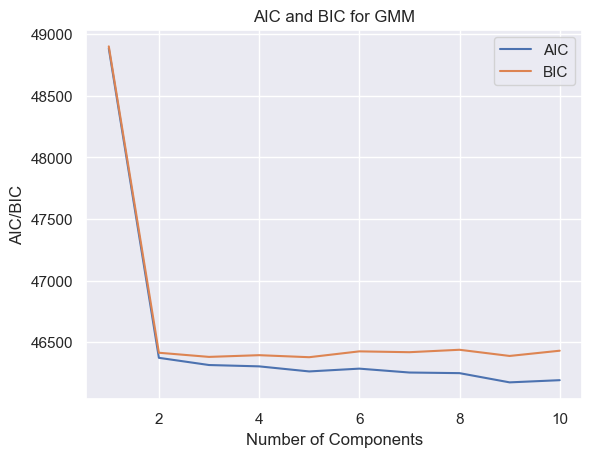

In [101]:
uif.gaussian_mixture_binning(df, featuresD, RANDOM_STATE)

In [102]:
# add to list
removeCols.extend(features)

# new category feature
newCol = discretization('TotalBilirubin_Addition', 'TotalBilirubin_Addition_CAT', 2, 'Bilirubin Addition')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_both = uf.insert_into_dataframe(df_both, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
Bilirubin Addition(-1-0),7521.0,7809.0,15330.0,49.060665,50.939335
Bilirubin Addition(0-4),6266.0,6581.0,12847.0,48.774033,51.225967
Unknown,99.0,50.0,149.0,66.442953,33.557047
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [103]:
pd.DataFrame(df[features]).describe().T

,count,mean,std,min,25%,50%,75%,max
TerminalTotalBilirubin_DON,28542.0,1.043629,1.424194,0.000000,0.50000,0.700000,1.100000,45.40000
TotalBilirubinTransplant_CAN,28289.0,0.993461,1.714805,0.100000,0.50000,0.700000,1.100000,80.00000
TotalBilirubin_Addition,28220.0,0.501616,0.575297,-1.203973,0.09531,0.470004,0.788457,4.38577


##### TotalDayWaitList_CAN

In [104]:
features = uf.get_feature_list(df, 'TotalDayWaitList')

                        count        mean       std  min   25%   50%    75%     max
TotalDayWaitList_CAN  28751.0  221.156551  376.9342  0.0  19.0  76.0  258.0  6412.0

:::: NaN Count:
TotalDayWaitList_CAN    0


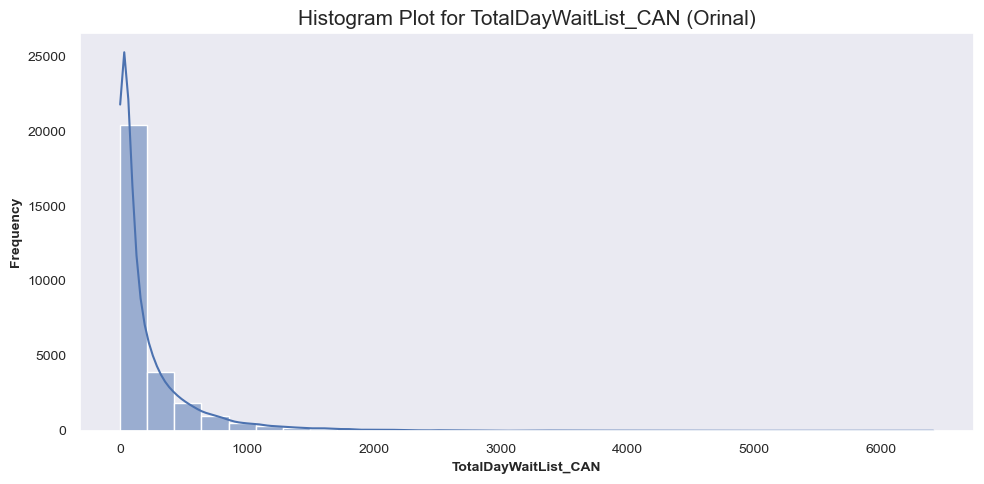

In [105]:
# plot
uv.plot_histogram(df, features, txt='(Orinal)', bins=30)

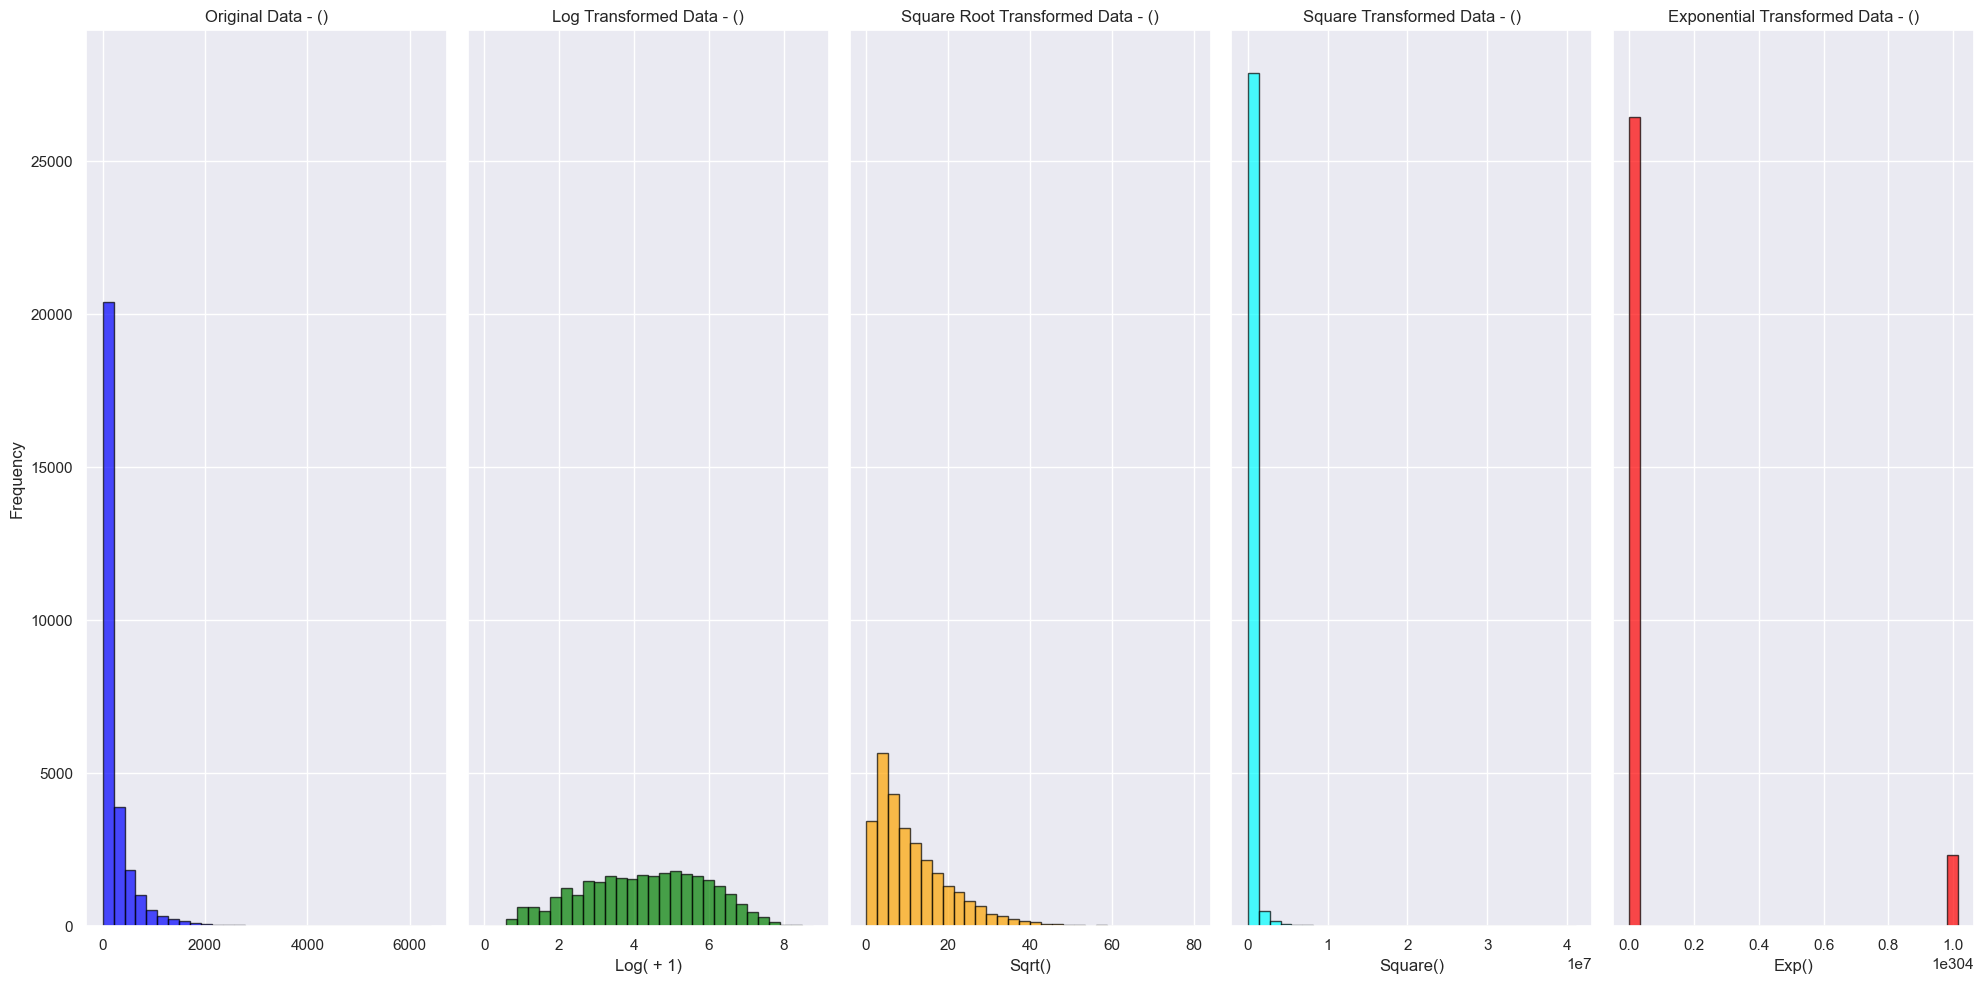

In [106]:
uv.plot_transform_distribution(df[features], txt='', bins=30, fig_size=(20, 10))

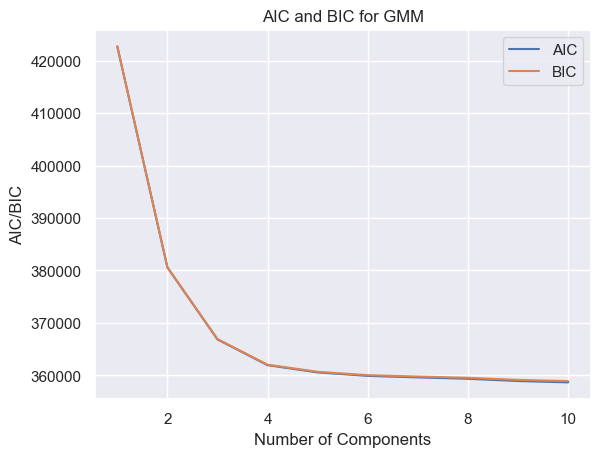

In [107]:
uif.gaussian_mixture_binning(df, features, RANDOM_STATE)

In [108]:
# add to list
removeCols.extend(features)

# new category feature
newCol = discretization('TotalDayWaitList_CAN', 'TotalDayWaitList_CAT_CAN', 4, 'WaitList Days')
# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, [newCol])
df_can = uf.insert_into_dataframe(df_can, [newCol])
# display
uf.category_contingency_survival(df, newCol)

Survival,Dead,Living,Row Total,Dead %,Living %
WaitList Days(0-19),4526.0,2544.0,7070.0,64.016973,35.983027
WaitList Days(19-76),3409.0,3625.0,7034.0,48.464601,51.535399
WaitList Days(76-258),2859.0,4226.0,7085.0,40.352858,59.647142
WaitList Days(258-6412),3092.0,4045.0,7137.0,43.323525,56.676475
Unknown,0.0,0.0,0.0,NaN,NaN
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


#### Remove Unwanted Features

In [109]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)
# initialize
removeCols = []

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 22 row(s) from df_can DataFrame.
Remove 14 row(s) from df_don DataFrame.
Remove 8 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 43 row(s) from df_numeric DataFrame.
Remove 26 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Listing_CAN', 'Age_Mean_CAN', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistra

#### Nominal

In [110]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDiseas

##### AllocationType_DON

In [111]:
features = uf.get_feature_list(df, 'AllocationType_DON')

                    count unique    top   freq
AllocationType_DON  28751      4  Local  14709

:::: NaN Count:
AllocationType_DON    0


In [112]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival          Dead   Living  Row Total     Dead %   Living %
Foreign Donor     12.0     15.0       27.0  44.444444  55.555556
Local           5207.0   9390.0    14597.0  35.671713  64.328287
National        5372.0   3032.0     8404.0  63.921942  36.078058
Regional        3295.0   2003.0     5298.0  62.193280  37.806720
Column Total   13886.0  14440.0    28326.0  49.022100  50.977900




##### AntiHypertensive_DON

In [113]:
features = uf.get_feature_list(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  28751      3  No  19094

:::: NaN Count:
AntiHypertensive_DON    0


In [114]:
for feature in features:
    print(uf.category_contingency_survival(df, feature, 'Survival'))
    print('\n')

Survival         Dead   Living  Row Total     Dead %   Living %
No             9075.0   9842.0    18917.0  47.972723  52.027277
Unknown          41.0     20.0       61.0  67.213115  32.786885
Yes            4770.0   4578.0     9348.0  51.026958  48.973042
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Antibody

In [115]:
features = uf.get_feature_list(df, 'Antibody')

                                       count unique       top   freq
AntibodyResultHBSAB_DON                28751      3   Unknown  24532
AntibodyResultRPR_VDRL_DON             28751      3  Negative  27968
Antibody_HEP_C_DON                     28751      3  Negative  27299
Hepatitis_B_CoreAntibody_CAN           28751      3  Negative  25699
Hepatitis_B_CoreAntibody_DON           28751      3  Negative  28146
SurfaceHBVAntibodyTotalTransplant_CAN  28751      5  Negative  13453

:::: NaN Count:
AntibodyResultHBSAB_DON                  0
AntibodyResultRPR_VDRL_DON               0
Antibody_HEP_C_DON                       0
Hepatitis_B_CoreAntibody_CAN             0
Hepatitis_B_CoreAntibody_DON             0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [116]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features).head()

,column1,column2,chi2,p_value,cramer_v
13,Hepatitis_B_CoreAntibody_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,1822.471516,0.000000e+00,0.178028
10,Antibody_HEP_C_DON,Hepatitis_B_CoreAntibody_DON,1680.296584,0.000000e+00,0.170943
11,Antibody_HEP_C_DON,SurfaceHBVAntibodyTotalTransplant_CAN,536.621581,9.699116e-111,0.096603
3,AntibodyResultHBSAB_DON,Hepatitis_B_CoreAntibody_DON,482.472863,4.136075e-103,0.091600
8,AntibodyResultRPR_VDRL_DON,SurfaceHBVAntibodyTotalTransplant_CAN,411.299759,7.161054e-84,0.084574


##### Antigen

###### Antigen CAN

In [117]:
features = uf.get_feature_list(df, '^Antigen.*_CAN')

                   count unique       top   freq
AntigenBW4_CAN     28751      3  Negative  22547
AntigenBW6_CAN     28751      3  Negative  20477
AntigenC1_CAN      28751      2  Negative  19487
AntigenC2_CAN      28751      2  Negative  20340
AntigenDQ1_CAN     28751      2  Negative  19207
AntigenDQ2_CAN     28751      2  Negative  20339
AntigenDR51_2_CAN  28751      3  Negative  27180
AntigenDR51_CAN    28751      3  Negative  20736
AntigenDR52_2_CAN  28751      3  Negative  27085
AntigenDR52_CAN    28751      3  Negative  20131
AntigenDR53_2_CAN  28751      3  Negative  27173
AntigenDR53_CAN    28751      3  Negative  20469
AntigenRA1_CAN     28751      3  Positive  26297
AntigenRA2_CAN     28751      3  Positive  23862
AntigenRB1_CAN     28751      3  Positive  26298
AntigenRB2_CAN     28751      3  Positive  25046
AntigenRDR1_CAN    28751      3  Positive  26297
AntigenRDR2_CAN    28751      3  Positive  24502

:::: NaN Count:
AntigenBW4_CAN       0
AntigenBW6_CAN       0
Antige

In [118]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
148,AntigenRB1_CAN,AntigenRDR1_CAN,56767.229680,0.0,0.993590
141,AntigenRA1_CAN,AntigenRDR1_CAN,56654.353485,0.0,0.992602
139,AntigenRA1_CAN,AntigenRB1_CAN,56468.758618,0.0,0.990975
90,AntigenDR51_2_CAN,AntigenDR53_2_CAN,53719.027570,0.0,0.966546
34,AntigenC1_CAN,AntigenDQ1_CAN,26393.532423,0.0,0.958125
109,AntigenDR52_2_CAN,AntigenDR53_2_CAN,50784.230733,0.0,0.939773
88,AntigenDR51_2_CAN,AntigenDR52_2_CAN,50753.655354,0.0,0.939490
101,AntigenDR51_CAN,AntigenDR53_CAN,50686.816940,0.0,0.938871
99,AntigenDR51_CAN,AntigenDR52_CAN,49963.996374,0.0,0.932153
33,AntigenC1_CAN,AntigenC2_CAN,24890.679981,0.0,0.930448


In [119]:
# new feature
df['Antigen_Positive_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['Antigen_Positive_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Antigen_Positive_Count_CAN'])

# add to list
removeCols.extend(features)

In [120]:
uf.category_contingency_survival(df, 'Antigen_Positive_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1123.0,1220.0,2343.0,47.930004,52.069996
2,0.0,2.0,2.0,0.000000,100.000000
3,41.0,46.0,87.0,47.126437,52.873563
4,128.0,234.0,362.0,35.359116,64.640884
5,1005.0,1493.0,2498.0,40.232186,59.767814
6,6472.0,6702.0,13174.0,49.127068,50.872932
7,22.0,83.0,105.0,20.952381,79.047619
8,60.0,140.0,200.0,30.000000,70.000000
9,97.0,163.0,260.0,37.307692,62.692308
10,108.0,223.0,331.0,32.628399,67.371601


###### Antigen DON

In [121]:
features = uf.get_feature_list(df, '^Antigen.*_DON')

                count unique       top   freq
AntigenDA1_DON  28751      2  Positive  28748
AntigenDA2_DON  28751      3  Positive  26301
AntigenDB1_DON  28751      2  Positive  28748
AntigenDB2_DON  28751      3  Positive  27440
AntigenDR1_DON  28751      2  Positive  28746
AntigenDR2_DON  28751      3  Positive  26775

:::: NaN Count:
AntigenDA1_DON    0
AntigenDA2_DON    0
AntigenDB1_DON    0
AntigenDB2_DON    0
AntigenDR1_DON    0
AntigenDR2_DON    0


In [122]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
1,AntigenDA1_DON,AntigenDB1_DON,19965.138811,0.0,0.833316
3,AntigenDA1_DON,AntigenDR1_DON,11977.916507,0.0,0.645452
10,AntigenDB1_DON,AntigenDR1_DON,11977.916507,0.0,0.645452
14,AntigenDR1_DON,AntigenDR2_DON,8452.646445,0.0,0.542213
0,AntigenDA1_DON,AntigenDA2_DON,6632.538221,0.0,0.480301
5,AntigenDA2_DON,AntigenDB1_DON,6632.538221,0.0,0.480301
2,AntigenDA1_DON,AntigenDB2_DON,5747.799750,0.0,0.447120
9,AntigenDB1_DON,AntigenDB2_DON,5747.799750,0.0,0.447120
4,AntigenDA1_DON,AntigenDR2_DON,5071.235036,0.0,0.419982
11,AntigenDB1_DON,AntigenDR2_DON,5071.235036,0.0,0.419982


In [123]:
# new feature
df['Antigen_Positive_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['Antigen_Positive_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Antigen_Positive_Count_DON'])

# add to list
removeCols.extend(features)

In [124]:
uf.category_contingency_survival(df, 'Antigen_Positive_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1.0,2.0,3.0,33.333333,66.666667
3,37.0,94.0,131.0,28.244275,71.755725
4,224.0,456.0,680.0,32.941176,67.058824
5,1548.0,2398.0,3946.0,39.229600,60.770400
6,12076.0,11490.0,23566.0,51.243317,48.756683
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### ArginnieManagement_DON

In [125]:
features = uf.get_feature_list(df, 'Arginnie')

                        count unique  top   freq
ArginnieManagement_DON  28751      3  Yes  19759

:::: NaN Count:
ArginnieManagement_DON    0


In [126]:
uf.category_contingency_survival(df, 'ArginnieManagement_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4101.0,4599.0,8700.0,47.137931,52.862069
Unknown,37.0,22.0,59.0,62.711864,37.288136
Yes,9748.0,9819.0,19567.0,49.818572,50.181428
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Biopsy_DON (REMOVE)

In [127]:
features = uf.get_feature_list(df, 'Biopsy')

            count unique              top   freq
Biopsy_DON  28751      4  Biopsy not done  28514

:::: NaN Count:
Biopsy_DON    0


In [128]:
uf.category_contingency_survival(df, features)

Survival,Dead,Living,Row Total,Dead %,Living %
Biopsy not done,13840.0,14403.0,28243.0,49.003293,50.996707
Unknown,39.0,22.0,61.0,63.934426,36.065574
"Yes, rejection confirmed",5.0,5.0,10.0,50.000000,50.000000
"Yes, rejection not confirmed",2.0,10.0,12.0,16.666667,83.333333
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [129]:
# add to lis: No Value added
removeCols.extend(features)

##### BloodGroup
- Reemove BloodGroup_CAN & BloodGroup_DON

In [130]:
features = uf.get_feature_list(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  28751      3  Identical  24619
BloodGroup_CAN        28751      8          O  11367
BloodGroup_DON        28751      8          O  14640

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [131]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
2,BloodGroup_CAN,BloodGroup_DON,47977.172763,0.0,0.488250
0,BloodGroupMatchLevel,BloodGroup_CAN,6196.568768,0.0,0.328272
1,BloodGroupMatchLevel,BloodGroup_DON,1640.020063,0.0,0.168882


In [132]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total      Dead %   Living %
Compatible     2040.0   2040.0     4080.0   50.000000  50.000000
Identical     11845.0  12400.0    24245.0   48.855434  51.144566
Incompatible      1.0      0.0        1.0  100.000000   0.000000
Column Total  13886.0  14440.0    28326.0   49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
A              5378.0   5794.0    11172.0  48.138203  51.861797
A1               44.0     23.0       67.0  65.671642  34.328358
A1B               2.0      3.0        5.0  40.000000  60.000000
A2                5.0      2.0        7.0  71.428571  28.571429
A2B               2.0      2.0        4.0  50.000000  50.000000
AB              731.0    838.0     1569.0  46.590185  53.409815
B              2181.0   2136.0     4317.0  50.521195  49.478805
O              5543.0   5642.0    11185.0  49.557443  50.442557
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living 

In [133]:
# add to removeCols
removeCols.extend(['BloodGroup_CAN','BloodGroup_DON'])

##### BloodPH_CAT_DON

In [134]:
features = uf.get_feature_list(df, 'BloodPH')

                 count unique     top   freq
BloodPH_CAT_DON  28751      4  Normal  17158

:::: NaN Count:
BloodPH_CAT_DON    0


In [135]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Acidic         1646.0   1874.0     3520.0  46.761364  53.238636
Alkaline       3901.0   3824.0     7725.0  50.498382  49.501618
Normal         8286.0   8719.0    17005.0  48.726845  51.273155
Unknown          53.0     23.0       76.0  69.736842  30.263158
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Bronchoscopy
- BronchoscopyLeft_DON & BronchoscopyRight_DON
- New Feature Bronchoscopy_Combined

In [136]:
features = uf.get_feature_list(df, 'Bronchoscopy')

                       count unique      top   freq
BronchoscopyLeft_DON   28751      3  Unknown  15037
BronchoscopyRight_DON  28751      3  Unknown  15257

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [137]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,BronchoscopyLeft_DON,BronchoscopyRight_DON,37802.044774,0.0,0.810805


In [138]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal       1531.0   1871.0     3402.0  45.002939  54.997061
Normal         4877.0   5331.0    10208.0  47.776254  52.223746
Unknown        7478.0   7238.0    14716.0  50.815439  49.184561
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal       1788.0   2043.0     3831.0  46.671887  53.328113
Normal         4559.0   5001.0     9560.0  47.688285  52.311715
Unknown        7539.0   7396.0    14935.0  50.478741  49.521259
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [139]:
# new feature
df['Bronchoscopy_Abnormal_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Abnormal'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['Bronchoscopy_Abnormal_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Bronchoscopy_Abnormal_Count_DON'])

# add to list
removeCols.extend(features)

In [140]:
uf.category_contingency_survival(df, 'Bronchoscopy_Abnormal_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,11835.0,11973.0,23808.0,49.710181,50.289819
1,783.0,1020.0,1803.0,43.427621,56.572379
2,1268.0,1447.0,2715.0,46.703499,53.296501
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### CMV

In [141]:
features = uf.get_feature_list(df, 'CMV')

                          count unique       top   freq
CMVStatus_Transplant_CAN  28751      3  Positive  16029
CMV_IGG_Transplant_CAN    28751      3   Unknown  20382
CMV_IGM_Transplant_CAN    28751      3   Unknown  22580
SerologyAntiCMV_DON       28751      3  Positive  17600

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [142]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
3,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,19281.876179,0.000000e+00,0.579073
0,CMVStatus_Transplant_CAN,CMV_IGG_Transplant_CAN,8680.260984,0.000000e+00,0.388530
1,CMVStatus_Transplant_CAN,CMV_IGM_Transplant_CAN,449.006713,7.121706e-96,0.088366
2,CMVStatus_Transplant_CAN,SerologyAntiCMV_DON,28.958426,7.970887e-06,0.022441
4,CMV_IGG_Transplant_CAN,SerologyAntiCMV_DON,11.285917,2.353184e-02,0.014010
5,CMV_IGM_Transplant_CAN,SerologyAntiCMV_DON,5.746781,2.188738e-01,0.009997


In [143]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       5890.0   5890.0    11780.0  50.000000  50.000000
Positive       7719.0   8276.0    15995.0  48.258831  51.741169
Unknown         277.0    274.0      551.0  50.272232  49.727768
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative        560.0   2799.0     3359.0  16.671628  83.328372
Positive        845.0   4165.0     5010.0  16.866267  83.133733
Unknown       12481.0   7476.0    19957.0  62.539460  37.460540
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1002.0   4867.0     5869.0  17.072755  82.927245
Positive         59.0    243.0      302.0  19.536424  80.463576
Unknown       12825.0   9330.0    22155.0  57.887610  42.112390
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Ro

In [144]:
features = uf.get_feature_list(df, 'CMV_I')

                        count unique      top   freq
CMV_IGG_Transplant_CAN  28751      3  Unknown  20382
CMV_IGM_Transplant_CAN  28751      3  Unknown  22580

:::: NaN Count:
CMV_IGG_Transplant_CAN    0
CMV_IGM_Transplant_CAN    0


In [145]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,19281.876179,0.0,0.579073


In [146]:
# new feature
df['CMV_Positive_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['CMV_Positive_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['CMV_Positive_Count_CAN'])

# add to list
removeCols.extend(features)

In [147]:
uf.category_contingency_survival(df, 'CMV_Positive_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13029.0,10245.0,23274.0,55.980923,44.019077
1,810.0,3982.0,4792.0,16.903172,83.096828
2,47.0,213.0,260.0,18.076923,81.923077
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Cancer
- CancerExtraCranial_DON & CancerIntraCranial_DON & CancerHistory_DON & CancerSkin_DON
- Consolidated Cancer_CountTotal_DON

In [148]:
features = uf.get_feature_list(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  28751      3  No  28326
CancerHistory_DON       28751      3  No  28182
CancerIntraCranial_DON  28751      3  No  28302
CancerSite_DON          28751     26  NO  28182
CancerSkin_DON          28751      3  No  28352

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSite_DON            0
CancerSkin_DON            0


In [149]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
5,CancerHistory_DON,CancerSite_DON,57502.000000,0.0,1.000000
3,CancerExtraCranial_DON,CancerSkin_DON,27802.026320,0.0,0.695339
8,CancerIntraCranial_DON,CancerSkin_DON,26694.789024,0.0,0.681352
1,CancerExtraCranial_DON,CancerIntraCranial_DON,26624.507684,0.0,0.680455
7,CancerIntraCranial_DON,CancerSite_DON,17813.137269,0.0,0.556581
4,CancerHistory_DON,CancerIntraCranial_DON,6499.199770,0.0,0.336193
9,CancerSite_DON,CancerSkin_DON,6428.821178,0.0,0.334368
6,CancerHistory_DON,CancerSkin_DON,4867.373893,0.0,0.290942
2,CancerExtraCranial_DON,CancerSite_DON,4183.428167,0.0,0.269727
0,CancerExtraCranial_DON,CancerHistory_DON,3913.154575,0.0,0.260869


In [150]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13744.0  14314.0    28058.0  48.984247  51.015753
Unknown         120.0     99.0      219.0  54.794521  45.205479
Yes              22.0     27.0       49.0  44.897959  55.102041
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13576.0  14192.0    27768.0  48.890810  51.109190
Unknown         119.0     71.0      190.0  62.631579  37.368421
Yes             191.0    177.0      368.0  51.902174  48.097826
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13733.0  14300.0    28033.0  48.988692  51.011308
Unknown         127.0    107.0      234.0  54.273504  45.726496
Yes              26.0     33.0       59.0  44.067797  55.932203
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival                          

In [151]:
# new feature
df['Cancer_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['Cancer_Yes_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Cancer_Yes_Count_DON'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Cancer_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13670.0,14235.0,27905.0,48.987637,51.012363
1,184.0,161.0,345.0,53.333333,46.666667
2,32.0,41.0,73.0,43.835616,56.164384
3,0.0,3.0,3.0,0.000000,100.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### CardiacArrest_DON

In [152]:
features = uf.get_feature_list(df, 'CardiacArrest')

                   count unique top   freq
CardiacArrest_DON  28751      3  No  26165

:::: NaN Count:
CardiacArrest_DON    0


In [153]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         308.0     17.0      325.0  94.769231   5.230769
No            12604.0  13345.0    25949.0  48.572199  51.427801
Yes             974.0   1078.0     2052.0  47.465887  52.534113
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Cause of Death
- CauseOfDeath_DON & DeathCircumstance_DON & DeathMechanism_DON
- Remove DeathCircumstance_DON & DeathMechanism_DON

In [154]:
features = uf.get_feature_list(df, 'Death')

                       count unique                        top   freq
CauseOfDeath_DON       28751      6                HEAD TRAUMA  13210
DeathCircumstance_DON  28751      8  DEATH FROM NATURAL CAUSES   6700
DeathMechanism_DON     28751     13               BLUNT INJURY   8046

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [155]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CauseOfDeath_DON,DeathMechanism_DON,68851.799331,0.0,0.692064
2,DeathCircumstance_DON,DeathMechanism_DON,66746.153888,0.0,0.575887
0,CauseOfDeath_DON,DeathCircumstance_DON,33251.453053,0.0,0.480943


In [156]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival                   Dead   Living  Row Total     Dead %   Living %
ANOXIA                   5621.0   4296.0     9917.0  56.680448  43.319552
CEREBROVASCULAR/STROKE   2045.0   2569.0     4614.0  44.321630  55.678370
CNS TUMOR                  64.0     61.0      125.0  51.200000  48.800000
HEAD TRAUMA              5839.0   7196.0    13035.0  44.794783  55.205217
Missing                     1.0      3.0        4.0  25.000000  75.000000
OTHER SPECIFY             316.0    315.0      631.0  50.079239  49.920761
Column Total            13886.0  14440.0    28326.0  49.022100  50.977900


Survival                      Dead   Living  Row Total     Dead %    Living %
Accident, Non-MVA           2812.0   2023.0     4835.0  58.159255   41.840745
CHILD-ABUSE                    0.0      1.0        1.0   0.000000  100.000000
DEATH FROM NATURAL CAUSES   3154.0   3439.0     6593.0  47.838617   52.161383
HOMICIDE                    1155.0   1406.0     2561.0  45.099570   54.900430
MVA             

In [157]:
# add to removeCols
removeCols.extend(['DeathCircumstance_DON', 'DeathMechanism_DON'])

##### CerebroVascularDisease_CAN

In [158]:
features = uf.get_feature_list(df, 'CerebroVascularDisease_CAN')

                            count unique top   freq
CerebroVascularDisease_CAN  28751      3  No  26646

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [159]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12816.0  13494.0    26310.0  48.711517  51.288483
Unknown         121.0     83.0      204.0  59.313725  40.686275
Yes             949.0    863.0     1812.0  52.373068  47.626932
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### ChestXray_DON

In [160]:
features = uf.get_feature_list(df, 'ChestXray')

               count unique       top   freq
ChestXray_DON  28751      3  Abnormal  21307

:::: NaN Count:
ChestXray_DON    0


In [161]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal      10635.0  10395.0    21030.0  50.570613  49.429387
Normal         2559.0   3353.0     5912.0  43.284844  56.715156
Unknown         692.0    692.0     1384.0  50.000000  50.000000
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Cigarette

In [162]:
features = uf.get_feature_list(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  28751      9  Unknown  16622
CigaretteHistory_DON     28751      3       No  24978
CigaretteUse_CAN         28751      3       No  16093

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [163]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival               Dead   Living  Row Total     Dead %   Living %
0-2 months            152.0    172.0      324.0  46.913580  53.086420
13-24 months          498.0    475.0      973.0  51.181912  48.818088
25-36 months          291.0    310.0      601.0  48.419301  51.580699
3-12 months           986.0   1081.0     2067.0  47.701984  52.298016
37-48 months          238.0    235.0      473.0  50.317125  49.682875
49-60 months          189.0    224.0      413.0  45.762712  54.237288
>60 months           3354.0   3722.0     7076.0  47.399661  52.600339
Continues to smoke     25.0     28.0       53.0  47.169811  52.830189
Unknown              8153.0   8193.0    16346.0  49.877646  50.122354
Column Total        13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            11957.0  12658.0    24615.0  48.576072  51.423928
Unknown         276.0    187.0      463.0  59.611231  40.388769
Yes            1653.0   1595.0     3

##### Citizenship
- Citizenship_CAN & Citizenship_DON
- New Feature Citizenship_Difference

In [164]:
features = uf.get_feature_list(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  28751      7  US Citizen  27682
Citizenship_DON  28751      6  US Citizen  25901

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [165]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Citizenship_CAN,Citizenship_DON,270.077231,1.934659e-40,0.043344


In [166]:
# convert to string
df[features] = df[features].astype(str)

# create New Feature (True = 1 & False = 0)
df['Citizenship_Difference'] = (df.Citizenship_CAN.str.replace(" ", "", regex=False).str.lower() == df.Citizenship_DON.str.replace(" ", "", regex=False).str.lower())

# convert to category
df = uf.convert_to_category(df, ['Citizenship_Difference']).copy()

# update DataFrame
df_nominal = uf.insert_into_dataframe(df_nominal, ['Citizenship_Difference'])
df_both = uf.insert_into_dataframe(df_both, ['Citizenship_Difference'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Citizenship_Difference', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
False,1996.0,1459.0,3455.0,57.771346,42.228654
True,11890.0,12981.0,24871.0,47.806682,52.193318
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Cocaine & Drug
- PastCocaineUse_DON & CocaineUse_DON & OtherDrugUse_DON & PastOtherDrugUse_DON
- Consolidated DrugUse_CountTotal_DON

In [167]:
features = uf.get_feature_list(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        28751      3  Unknown  23279
OtherDrugUse_DON      28751      3  Unknown  14189
PastCocaineUse_DON    28751      3       No  21715
PastOtherDrugUse_DON  28751      3      Yes  15935

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [168]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CocaineUse_DON,PastCocaineUse_DON,23971.879650,0.0,0.645668
4,OtherDrugUse_DON,PastOtherDrugUse_DON,23731.359785,0.0,0.642421
5,PastCocaineUse_DON,PastOtherDrugUse_DON,16691.291125,0.0,0.538770
0,CocaineUse_DON,OtherDrugUse_DON,4163.284826,0.0,0.269077
3,OtherDrugUse_DON,PastCocaineUse_DON,2755.175941,0.0,0.218894
2,CocaineUse_DON,PastOtherDrugUse_DON,2496.564431,0.0,0.208367


In [169]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             1054.0   1102.0     2156.0  48.886827  51.113173
Unknown       10882.0  12035.0    22917.0  47.484400  52.515600
Yes            1950.0   1303.0     3253.0  59.944666  40.055334
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             1073.0   1396.0     2469.0  43.458890  56.541110
Unknown        6221.0   7705.0    13926.0  44.671837  55.328163
Yes            6592.0   5339.0    11931.0  55.251027  44.748973
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            10099.0  11420.0    21519.0  46.930619  53.069381
Unknown         303.0    253.0      556.0  54.496403  45.503597
Yes            3484.0   2767.0     6251.0  55.735082  44.264918
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Ro

In [170]:
# new feature
df['DrugUse_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['DrugUse_Yes_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['DrugUse_Yes_Count_DON'])

# add to removeCols
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'DrugUse_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,5113.0,6585.0,11698.0,43.708326,56.291674
1,1361.0,1721.0,3082.0,44.159637,55.840363
2,4848.0,4291.0,9139.0,53.047379,46.952621
3,993.0,797.0,1790.0,55.474860,44.525140
4,1571.0,1046.0,2617.0,60.030569,39.969431
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### CoronaryAngiogram_DON

In [171]:
features = uf.get_feature_list(df, 'Coronary')

                       count unique      top   freq
CoronaryAngiogram_DON  28751      3  Unknown  18297

:::: NaN Count:
CoronaryAngiogram_DON    0


In [172]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal        482.0    420.0      902.0  53.436807  46.563193
Normal         5163.0   4265.0     9428.0  54.762410  45.237590
Unknown        8241.0   9755.0    17996.0  45.793510  54.206490
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### CrossMatchDone

In [173]:
features = uf.get_feature_list(df, 'CrossMatch')

                count unique  top   freq
CrossMatchDone  28751      3  Yes  26524

:::: NaN Count:
CrossMatchDone    0


In [174]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         424.0     83.0      507.0  83.629191  16.370809
No              726.0    825.0     1551.0  46.808511  53.191489
Yes           12736.0  13532.0    26268.0  48.484848  51.515152
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### DeceasedRetyped_DON

In [175]:
features = uf.get_feature_list(df, 'Deceased')

                     count unique  top   freq
DeceasedRetyped_DON  28751      3  Yes  17177

:::: NaN Count:
DeceasedRetyped_DON    0


In [176]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         424.0     83.0      507.0  83.629191  16.370809
No             4566.0   6270.0    10836.0  42.137320  57.862680
Yes            8896.0   8087.0    16983.0  52.381794  47.618206
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### DefibrillatorImplantRegistration_CAN

In [177]:
features = uf.get_feature_list(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  28751      3  Yes  21153

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [178]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             3781.0   3254.0     7035.0  53.745558  46.254442
Unknown         264.0    114.0      378.0  69.841270  30.158730
Yes            9841.0  11072.0    20913.0  47.056855  52.943145
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Diabetes
- DiabetesType_CAN & Diabetes_DON & InsulinManagement_DON

In [179]:
features = uf.get_feature_list(df, 'Diabetes|Insulin')

                       count unique  top   freq
DiabetesHistory_DON    28751      6   No  27502
DiabetesType_CAN       28751      6   No  20387
Diabetes_DON           28751      3   No  27502
InsulinManagement_DON  28751      3  Yes  16387

:::: NaN Count:
DiabetesHistory_DON      0
DiabetesType_CAN         0
Diabetes_DON             0
InsulinManagement_DON    0


In [180]:
df.DiabetesType_CAN.value_counts()

DiabetesType_CAN
No              20387
Type II          7508
Type I            388
Type Unknown      254
Type Other        119
Unknown            95
Name: count, dtype: int64

In [181]:
# define a function to categorize the results
def categorizeReMap(value):
    if value in ['No']:
        return value
    elif value in ['Unknown']:
        return value
    else:
        return 'Yes'

In [182]:
df.DiabetesType_CAN = df.DiabetesType_CAN.map(categorizeReMap)

In [183]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival                  Dead   Living  Row Total     Dead %   Living %
No                     13239.0  13862.0    27101.0  48.850596  51.149404
Unknown                  125.0     62.0      187.0  66.844920  33.155080
Yes, 0-5 Years           253.0    258.0      511.0  49.510763  50.489237
Yes, 6-10 Years           72.0     94.0      166.0  43.373494  56.626506
Yes, >10 Years           135.0    128.0      263.0  51.330798  48.669202
Yes, Duration Unknown     62.0     36.0       98.0  63.265306  36.734694
Column Total           13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             9752.0  10383.0    20135.0  48.433077  51.566923
Unknown          33.0     10.0       43.0  76.744186  23.255814
Yes            4101.0   4047.0     8148.0  50.331370  49.668630
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13239.0  13862

##### Diagnosis
- WaitListDiagnosisCode_CAN & DiagnosisAtListing_CAN & PrimaryDiagnosisType_CAN
- Remove WaitListDiagnosisCode_CAN & DiagnosisAtListing_CAN

In [184]:
features = uf.get_feature_list(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     28751     38  DILATED MYOPATHY: IDIOPATHIC  9941
PrimaryDiagnosisType_CAN   28751     37  DILATED MYOPATHY: IDIOPATHIC  9772
WaitListDiagnosisCode_CAN  28751     37  DILATED MYOPATHY: IDIOPATHIC  9907

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [185]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiagnosisAtListing_CAN,WaitListDiagnosisCode_CAN,508578.441871,0.0,0.700973
0,DiagnosisAtListing_CAN,PrimaryDiagnosisType_CAN,502566.760089,0.0,0.696818
2,PrimaryDiagnosisType_CAN,WaitListDiagnosisCode_CAN,395745.323612,0.0,0.618344


In [186]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
72,PrimaryDiagnosisType_CAN,RECIPIENT PRIMARY DIAGNOSIS,TRR>TCR,1987-10-01,NaT,PATIENT STATUS/CLINICAL INFORMATION,NUM,ALL_DGN,"THIS FIELD DRAWS FROM ""AT TRANSPLANT"" AND IF NOT THERE THEN FROM TCR.",DIAG,Category,FMTNAME: TH_DGN
270,DiagnosisAtListing_CAN,CANDIDATE DIAGNOSIS AT LISTING,TCR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,ALL_DGN,,TCR_DGN,Category,FMTNAME: TH_DGN
272,WaitListDiagnosisCode_CAN,Waitlist CANDIDATE DIAGNOSIS,WL DATA,NaT,NaT,,NUM,ALL_DGN,,THORACIC_DGN,Category,FMTNAME: TH_DGN


In [187]:
# add to removeCols
removeCols.extend(['WaitListDiagnosisCode_CAN', 'DiagnosisAtListing_CAN'])

##### Dialysis
- DialysisBetweenListingTransplant_CAN & DialysisPriorListing_CAN
- New Feature Dialysis_Combine_Count_CAN

In [188]:
features = uf.get_feature_list(df, 'Dialysis')

                                           count unique          top   freq
DialysisBetweenRegistrationTransplant_CAN  28751      3           No  27012
DialysisPriorRegistration_CAN              28751      3           No  26772
DialysisTypeRegistration_CAN               28751      6  No dialysis  27851

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPriorRegistration_CAN                0
DialysisTypeRegistration_CAN                 0


In [189]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,DialysisBetweenRegistrationTransplant_CAN,DialysisPriorRegistration_CAN,50757.482595,0.0,0.939525
2,DialysisPriorRegistration_CAN,DialysisTypeRegistration_CAN,20359.063710,0.0,0.595028
1,DialysisBetweenRegistrationTransplant_CAN,DialysisTypeRegistration_CAN,13129.242755,0.0,0.477835


In [190]:
# new feature
df['Dialysis_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['Dialysis_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Dialysis_Yes_Count_CAN'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Dialysis_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13004.0,13804.0,26808.0,48.507908,51.492092
1,119.0,111.0,230.0,51.739130,48.260870
2,763.0,525.0,1288.0,59.239130,40.760870
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Diuretic
- Diuretics_DON & SynthicAntiDiureticHormone_DON
- New Feature Diuretics_Combined_DON

In [191]:
features = uf.get_feature_list(df, 'Diuretic')

                                count unique  top   freq
Diuretics_DON                   28751      3  Yes  19986
SynthicAntiDiureticHormone_DON  28751      3   No  24575

:::: NaN Count:
Diuretics_DON                     0
SynthicAntiDiureticHormone_DON    0


In [192]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Diuretics_DON,SynthicAntiDiureticHormone_DON,27297.996273,0.0,0.689007


In [193]:
# new feature
df['Diuretics_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['Diuretics_Yes_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Diuretics_Yes_Count_DON'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Diuretics_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3793.0,3404.0,7197.0,52.702515,47.297485
1,8917.0,9583.0,18500.0,48.200000,51.800000
2,1176.0,1453.0,2629.0,44.731837,55.268163
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### EpsteinBarr
- EpsteinBarrSeroStatusTransplant_CAN & EpsteinBarr_IGG_DON & EpsteinBarr_IGM_DON
- These differences make EpsteinBarr_IGG_DON and EpsteinBarr_IGM_DON complementary markers for diagnosing and staging Epstein-Barr virus infections in donors.

In [194]:
features = uf.get_feature_list(df, 'EpsteinBarr.*CAN')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  28751      3  Positive  23469

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0


In [195]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1362.0   1480.0     2842.0  47.923997  52.076003
Positive      11734.0  11684.0    23418.0  50.106755  49.893245
Unknown         790.0   1276.0     2066.0  38.238141  61.761859
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [196]:
features = uf.get_feature_list(df, 'EpsteinBarr.*DON')

                     count unique       top   freq
EpsteinBarr_IGG_DON  28751      3  Positive  25618
EpsteinBarr_IGM_DON  28751      3  Negative  22991

:::: NaN Count:
EpsteinBarr_IGG_DON    0
EpsteinBarr_IGM_DON    0


In [197]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative        916.0    835.0     1751.0  52.312964  47.687036
Positive      12305.0  12935.0    25240.0  48.751981  51.248019
Unknown         665.0    670.0     1335.0  49.812734  50.187266
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      11018.0  11629.0    22647.0  48.651035  51.348965
Positive        190.0    208.0      398.0  47.738693  52.261307
Unknown        2678.0   2603.0     5281.0  50.710093  49.289907
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [198]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,1944.074382,0.0,0.183872


In [199]:
# new feature
df['EpsteinBarr_Positive_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['EpsteinBarr_Positive_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['EpsteinBarr_Positive_Count_DON'])

# add to list
removeCols.extend(features)

In [200]:
uf.category_contingency_survival(df, 'EpsteinBarr_Positive_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1566.0,1491.0,3057.0,51.226693,48.773307
1,12145.0,12755.0,24900.0,48.775100,51.224900
2,175.0,194.0,369.0,47.425474,52.574526
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Ethnicity

In [201]:
features = uf.get_feature_list(df, 'Ethnicity')

               count unique                  top   freq
Ethnicity_CAN  28751      7  White, Non-Hispanic  18252
Ethnicity_DON  28751      7  White, Non-Hispanic  18291

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [202]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Ethnicity_CAN,Ethnicity_DON,631.924348,5.572322e-110,0.060524


In [203]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival                                   Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                     44.0     39.0       83.0  53.012048  46.987952
Asian                                     524.0    501.0     1025.0  51.121951  48.878049
Black                                    3318.0   3119.0     6437.0  51.545751  48.454249
Hispanic                                 1299.0   1202.0     2501.0  51.939224  48.060776
Multiracial                                79.0     83.0      162.0  48.765432  51.234568
Native Hawaiian/other Pacific Islander     46.0     64.0      110.0  41.818182  58.181818
White, Non-Hispanic                      8576.0   9432.0    18008.0  47.623279  52.376721
Column Total                            13886.0  14440.0    28326.0  49.022100  50.977900


Survival                                   Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                     87.0     82.0      169.0  51.479290  48.520710
Asian   

##### Gender
- New Feature Gender_Difference

In [204]:
features = uf.get_feature_list(df, 'Gender')

            count unique top   freq
Gender_CAN  28751      2   M  21055
Gender_DON  28751      2   M  20345

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [205]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Gender_CAN,Gender_DON,5238.152816,0.0,0.426838


In [206]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
F              3733.0   3856.0     7589.0  49.189617  50.810383
M             10153.0  10584.0    20737.0  48.960795  51.039205
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
F              4002.0   4317.0     8319.0  48.106744  51.893256
M              9884.0  10123.0    20007.0  49.402709  50.597291
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [207]:
# convert to string
df[features] = df[features].astype(str)

# create New Feature (True = 1 & False = 0)
df['Gender_Difference'] = (df.Gender_CAN.str.replace(" ", "", regex=False).str.lower() == df.Gender_DON.str.replace(" ", "", regex=False).str.lower())

# convert to category
df = uf.convert_to_category(df, ['Gender_Difference']).copy()

# update DataFrame
df_nominal = uf.insert_into_dataframe(df_nominal, ['Gender_Difference'])
df_both = uf.insert_into_dataframe(df_both, ['Gender_Difference'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Gender_Difference', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
False,3097.0,3477.0,6574.0,47.109827,52.890173
True,10789.0,10963.0,21752.0,49.600037,50.399963
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### HBV
- HBV_NAT_Result_CAN & HBV_NAT_Result_DON & SurfaceHBVAntibodyTotalTransplant_CAN

In [208]:
features = uf.get_feature_list(df, 'HBV')

                                       count unique       top   freq
HBV_NAT_Result_CAN                     28751      3   Unknown  26413
HBV_NAT_Result_DON                     28751      3  Negative  20051
SurfaceHBVAntibodyTotalTransplant_CAN  28751      5  Negative  13453

:::: NaN Count:
HBV_NAT_Result_CAN                       0
HBV_NAT_Result_DON                       0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [209]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
2,HBV_NAT_Result_DON,SurfaceHBVAntibodyTotalTransplant_CAN,21382.150726,0.000000e+00,0.609796
0,HBV_NAT_Result_CAN,HBV_NAT_Result_DON,1459.778121,0.000000e+00,0.159332
1,HBV_NAT_Result_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,1162.147430,1.444370e-245,0.142164


In [210]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       2046.0    256.0     2302.0  88.879235  11.120765
Positive         20.0      2.0       22.0  90.909091   9.090909
Unknown       11820.0  14182.0    26002.0  45.458042  54.541958
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12397.0   7229.0    19626.0  63.166208  36.833792
Positive          9.0      5.0       14.0  64.285714  35.714286
Unknown        1480.0   7206.0     8686.0  17.038913  82.961087
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Missing        1827.0   7178.0     9005.0  20.288728  79.711272
Negative       8259.0   5150.0    13409.0  61.592960  38.407040
Not Done        427.0    449.0      876.0  48.744292  51.255708
Positive       3303.0   1563.0     4866.0  67.879162  32.120838
Unknown          70.0    100.0      

In [211]:
# new feature
df['HBV_Positive_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['HBV_Positive_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['HBV_Positive_Count'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'HBV_Positive_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,10571.0,12871.0,23442.0,45.094275,54.905725
1,3299.0,1568.0,4867.0,67.783029,32.216971
2,15.0,1.0,16.0,93.750000,6.250000
3,1.0,0.0,1.0,100.000000,0.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### HCV
- HCV_NAT_PreTranspant_CAN & HCV_NAT_Result_DON

In [212]:
features = uf.get_feature_list(df, 'HCV')

                          count unique       top   freq
HCV_NAT_PreTranspant_CAN  28751      3   Unknown  25693
HCV_NAT_Result_DON        28751      3  Negative  19230

:::: NaN Count:
HCV_NAT_PreTranspant_CAN    0
HCV_NAT_Result_DON          0


In [213]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HCV_NAT_PreTranspant_CAN,HCV_NAT_Result_DON,1801.242041,0.0,0.176988


In [214]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       2634.0    369.0     3003.0  87.712288  12.287712
Positive         35.0      1.0       36.0  97.222222   2.777778
Unknown       11217.0  14070.0    25287.0  44.358761  55.641239
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      11625.0   7207.0    18832.0  61.730034  38.269966
Positive        796.0    104.0      900.0  88.444444  11.555556
Unknown        1465.0   7129.0     8594.0  17.046777  82.953223
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [215]:
# new feature
df['HCV_Positive_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['HCV_Positive_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['HCV_Positive_Count'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'HCV_Positive_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13068.0,14335.0,27403.0,47.688209,52.311791
1,805.0,105.0,910.0,88.461538,11.538462
2,13.0,0.0,13.0,100.000000,0.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### HEP
- SurfaceAntigenHEP_B_CAN & HEP_C_SerostatusStatus_CAN & SurfaceAntigenHEP_B_DON & Antibody_HEP_C_DON

In [216]:
features = uf.get_feature_list(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          28751      3  Negative  27299
HEP_C_SerostatusStatus_CAN  28751      3  Negative  27136
SurfaceAntigenHEP_B_CAN     28751      3  Negative  27403
SurfaceAntigenHEP_B_DON     28751      3  Negative  28698

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [217]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
3,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_CAN,14444.411374,0.000000e+00,0.501197
2,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_DON,605.905202,8.168887e-130,0.102650
0,Antibody_HEP_C_DON,HEP_C_SerostatusStatus_CAN,69.057920,3.587944e-14,0.034655
5,SurfaceAntigenHEP_B_CAN,SurfaceAntigenHEP_B_DON,14.186913,6.721791e-03,0.015707
1,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_CAN,7.706414,1.029443e-01,0.011577
4,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_DON,1.953025,7.443987e-01,0.005828


In [218]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12653.0  14266.0    26919.0  47.003975  52.996025
Positive       1231.0    170.0     1401.0  87.865810  12.134190
Unknown           2.0      4.0        6.0  33.333333  66.666667
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      13276.0  13796.0    27072.0  49.039598  50.960402
Positive        326.0    269.0      595.0  54.789916  45.210084
Unknown         284.0    375.0      659.0  43.095599  56.904401
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      13409.0  13932.0    27341.0  49.043561  50.956439
Positive        208.0    201.0      409.0  50.855746  49.144254
Unknown         269.0    307.0      576.0  46.701389  53.298611
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Ro

In [219]:
features = uf.get_feature_list(df, 'SurfaceAntigen')

                         count unique       top   freq
SurfaceAntigenHEP_B_CAN  28751      3  Negative  27403
SurfaceAntigenHEP_B_DON  28751      3  Negative  28698

:::: NaN Count:
SurfaceAntigenHEP_B_CAN    0
SurfaceAntigenHEP_B_DON    0


In [220]:
# new feature
df['SurfaceAntigenHEP_B_Positive_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['SurfaceAntigenHEP_B_Positive_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['SurfaceAntigenHEP_B_Positive_Count'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'SurfaceAntigenHEP_B_Positive_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13665.0,14233.0,27898.0,48.982006,51.017994
1,220.0,206.0,426.0,51.643192,48.356808
2,1.0,1.0,2.0,50.000000,50.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### HIV
- HIV_SeroStatusTransplant_CAN & HIV_NAT_PreTransplant_CAN & HIV_NAT_Result_DON & HIV_Risk_DON

In [221]:
features = uf.get_feature_list(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     28751      3   Unknown  26601
HIV_NAT_Result_DON            28751      2  Negative  20122
HIV_Risk_DON                  28751      3        No  21178
HIV_SeroStatusTransplant_CAN  28751      3  Negative  27604

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [222]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HIV_NAT_PreTransplant_CAN,HIV_NAT_Result_DON,987.268290,4.143953e-215,0.185307
3,HIV_NAT_Result_DON,HIV_Risk_DON,772.179932,2.105030e-168,0.163883
2,HIV_NAT_PreTransplant_CAN,HIV_SeroStatusTransplant_CAN,973.110279,2.397792e-209,0.130089
1,HIV_NAT_PreTransplant_CAN,HIV_Risk_DON,106.112799,4.906205e-22,0.042958
4,HIV_NAT_Result_DON,HIV_SeroStatusTransplant_CAN,11.975024,2.509902e-03,0.020409
5,HIV_Risk_DON,HIV_SeroStatusTransplant_CAN,11.692563,1.979005e-02,0.014260


In [223]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1884.0    240.0     2124.0  88.700565  11.299435
Positive         10.0      1.0       11.0  90.909091   9.090909
Unknown       11992.0  14199.0    26191.0  45.786721  54.213279
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12416.0   7281.0    19697.0  63.034980  36.965020
Unknown        1470.0   7159.0     8629.0  17.035578  82.964422
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             9661.0  11192.0    20853.0  46.329065  53.670935
Unknown           5.0      7.0       12.0  41.666667  58.333333
Yes            4220.0   3241.0     7461.0  56.560783  43.439217
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      13539.0  13999.0    

In [224]:
# add to list
removeCols.extend(features)

# new feature
df['HIV_Positive_Count'] = df[features].apply(lambda row: row.isin(['Positive', 'Yes']).sum(), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['HIV_Positive_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['HIV_Positive_Count'])

# display
uf.category_contingency_survival(df, 'HIV_Positive_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,9623.0,11172.0,20795.0,46.275547,53.724453
1,4231.0,3258.0,7489.0,56.496194,43.503806
2,30.0,10.0,40.0,75.000000,25.000000
3,2.0,0.0,2.0,100.000000,0.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Heart
- NonHeartBeating_DON & HeartProcedureType_CAN

In [225]:
features = uf.get_feature_list(df, 'Heart')

                        count unique                 top   freq
HeartProcedureType_CAN  28751      5  Orthotopic Bicaval  23070
NonHeartBeating_DON     28751      3                  No  28428

:::: NaN Count:
HeartProcedureType_CAN    0
NonHeartBeating_DON       0


In [226]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HeartProcedureType_CAN,NonHeartBeating_DON,472.502622,5.557213e-97,0.090649


In [227]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival                           Dead   Living  Row Total      Dead %   Living %
Heterotopic                         7.0      8.0       15.0   46.666667  53.333333
Unknown                            54.0      0.0       54.0  100.000000   0.000000
Orthotopic Bicaval              11296.0  11725.0    23021.0   49.068242  50.931758
Orthotopic Total (Bicaval, PV)    389.0    281.0      670.0   58.059701  41.940299
Orthotopic Traditional           2140.0   2426.0     4566.0   46.868156  53.131844
Column Total                    13886.0  14440.0    28326.0   49.022100  50.977900


Survival         Dead   Living  Row Total      Dead %   Living %
Unknown           2.0      3.0        5.0   40.000000  60.000000
No            13611.0  14437.0    28048.0   48.527524  51.472476
Yes             273.0      0.0      273.0  100.000000   0.000000
Column Total  13886.0  14440.0    28326.0   49.022100  50.977900




##### HeavyAlcoholUse_DON

In [228]:
features = uf.get_feature_list(df, 'Heavy')

                     count unique top   freq
HeavyAlcoholUse_DON  28751      3  No  23139

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [229]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10994.0  11822.0    22816.0  48.185484  51.814516
Unknown         407.0    291.0      698.0  58.309456  41.690544
Yes            2485.0   2327.0     4812.0  51.641729  48.358271
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### HeparinManagement_DON

In [230]:
features = uf.get_feature_list(df, 'Heparin')

                       count unique  top   freq
HeparinManagement_DON  28751      3  Yes  28085

:::: NaN Count:
HeparinManagement_DON    0


In [231]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No              179.0    273.0      452.0  39.601770  60.398230
Unknown          36.0     18.0       54.0  66.666667  33.333333
Yes           13671.0  14149.0    27820.0  49.140906  50.859094
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Hepatitis

In [232]:
features = uf.get_feature_list(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  28751      3  Negative  25699
Hepatitis_B_CoreAntibody_DON  28751      3  Negative  28146

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [233]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,17.106367,0.001843,0.017248


In [234]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12689.0  12948.0    25637.0  49.494871  50.505129
Positive        632.0    654.0     1286.0  49.144635  50.855365
Unknown         565.0    838.0     1403.0  40.270848  59.729152
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      13539.0  14194.0    27733.0  48.819096  51.180904
Positive        340.0    236.0      576.0  59.027778  40.972222
Unknown           7.0     10.0       17.0  41.176471  58.823529
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [235]:
# new feature
df['Hepatitis_B_Positive_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['Hepatitis_B_Positive_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Hepatitis_B_Positive_Count'])

# add to list
removeCols.extend(features) # removing HIV risk
# display
uf.category_contingency_survival(df, 'Hepatitis_B_Positive_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,12932.0,13576.0,26508.0,48.785272,51.214728
1,936.0,838.0,1774.0,52.762120,47.237880
2,18.0,26.0,44.0,40.909091,59.090909
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### HypertensionHistory_DON

In [236]:
features = uf.get_feature_list(df, 'HypertensionH')

                         count unique top   freq
HypertensionHistory_DON  28751      3  No  24127

:::: NaN Count:
HypertensionHistory_DON    0


In [237]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11586.0  12188.0    23774.0  48.733911  51.266089
Unknown         138.0     81.0      219.0  63.013699  36.986301
Yes            2162.0   2171.0     4333.0  49.896146  50.103854
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Infection
- InfectionTherapyIV_CAN & BloodInfectionSource_DON & OtherInfectionSource_DON & PulmonaryInfection_DON & UrineInfection_DON & InfectionClinical_DON

In [238]:
features = uf.get_feature_list(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  28751      3   No  25920
InfectionClinical_DON     28751      3  Yes  21856
InfectionTherapyIV_CAN    28751      3   No  25055
OtherInfectionSource_DON  28751      3   No  19772
PulmonaryInfection_DON    28751      3  Yes  19988
UrineInfection_DON        28751      3   No  25408

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [239]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12410.0  13113.0    25523.0  48.622811  51.377189
Unknown           1.0      2.0        3.0  33.333333  66.666667
Yes            1475.0   1325.0     2800.0  52.678571  47.321429
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             2910.0   3663.0     6573.0  44.272022  55.727978
Unknown          60.0     60.0      120.0  50.000000  50.000000
Yes           10916.0  10717.0    21633.0  50.459945  49.540055
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            12205.0  12797.0    25002.0  48.816095  51.183905
Unknown         139.0    231.0      370.0  37.567568  62.432432
Yes            1542.0   1412.0     2954.0  52.200406  47.799594
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Ro

In [240]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
4,BloodInfectionSource_DON,UrineInfection_DON,28905.994660,0.000000e+00,0.709010
14,PulmonaryInfection_DON,UrineInfection_DON,28877.046444,0.000000e+00,0.708655
3,BloodInfectionSource_DON,PulmonaryInfection_DON,28822.657625,0.000000e+00,0.707987
6,InfectionClinical_DON,OtherInfectionSource_DON,28751.000000,0.000000e+00,0.707107
12,OtherInfectionSource_DON,PulmonaryInfection_DON,21482.758739,0.000000e+00,0.611228
7,InfectionClinical_DON,PulmonaryInfection_DON,20992.981316,0.000000e+00,0.604221
5,InfectionClinical_DON,InfectionTherapyIV_CAN,2656.279783,0.000000e+00,0.214929
8,InfectionClinical_DON,UrineInfection_DON,1504.388043,0.000000e+00,0.161748
0,BloodInfectionSource_DON,InfectionClinical_DON,1301.826268,1.337234e-280,0.150465
13,OtherInfectionSource_DON,UrineInfection_DON,1201.489090,7.574802e-259,0.144550


In [241]:
features = uf.get_feature_list(df, 'Infection.*DON')

                          count unique  top   freq
BloodInfectionSource_DON  28751      3   No  25920
InfectionClinical_DON     28751      3  Yes  21856
OtherInfectionSource_DON  28751      3   No  19772
PulmonaryInfection_DON    28751      3  Yes  19988
UrineInfection_DON        28751      3   No  25408

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [242]:
# new feature
df['Infection_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insert_into_dataframe(df_don, ['Infection_Yes_Count_DON'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Infection_Yes_Count_DON'])

# add to list
removeCols.extend(features)

In [243]:
uf.category_contingency_survival(df, 'Infection_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2970.0,3723.0,6693.0,44.374720,55.625280
2,8043.0,8103.0,16146.0,49.814195,50.185805
3,2481.0,2236.0,4717.0,52.596990,47.403010
4,367.0,336.0,703.0,52.204836,47.795164
5,25.0,42.0,67.0,37.313433,62.686567
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


In [244]:
features = uf.get_feature_list(df, 'Infection.*CAN')

                        count unique top   freq
InfectionTherapyIV_CAN  28751      3  No  25055

:::: NaN Count:
InfectionTherapyIV_CAN    0


In [245]:
uf.category_contingency_survival(df, 'InfectionTherapyIV_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
No,12205.0,12797.0,25002.0,48.816095,51.183905
Unknown,139.0,231.0,370.0,37.567568,62.432432
Yes,1542.0,1412.0,2954.0,52.200406,47.799594
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Inotropic
- Remove InotropicAgent_DON

In [246]:
features = uf.get_feature_list(df, 'Inotropic')

                                    count unique      top   freq
InotropicAgent_DON                  28751      7  Unknown  17558
InotropicMedicationProcurement_DON  28751      3       No  17310

:::: NaN Count:
InotropicAgent_DON                    0
InotropicMedicationProcurement_DON    0


In [247]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,InotropicAgent_DON,InotropicMedicationProcurement_DON,28746.79423,0.0,0.707055


In [248]:
for feature in features:
    print(uf.category_contingency_survival(df, feature, 'Survival').to_string(), feature)
    print("\n")

# append to removceCols
removeCols.extend(['InotropicAgent_DON'])

Survival           Dead   Living  Row Total     Dead %   Living %
Dobutamine        314.0    286.0      600.0  52.333333  47.666667
Dopamine          609.0   1271.0     1880.0  32.393617  67.606383
Epinephrine        71.0     55.0      126.0  56.349206  43.650794
Levophed         1553.0   1767.0     3320.0  46.777108  53.222892
Unknown          8834.0   8380.0    17214.0  51.318694  48.681306
Neosynephrine    2148.0   2404.0     4552.0  47.188049  52.811951
Other, specify    357.0    277.0      634.0  56.309148  43.690852
Column Total    13886.0  14440.0    28326.0  49.022100  50.977900 InotropicAgent_DON


Survival         Dead   Living  Row Total     Dead %   Living %
No             8779.0   8341.0    17120.0  51.279206  48.720794
Unknown          55.0     39.0       94.0  58.510638  41.489362
Yes            5052.0   6060.0    11112.0  45.464363  54.535637
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900 InotropicMedicationProcurement_DON




##### Inotoropes

##### IntropesIV
- InotropesIVRegistration_CAN & InotropesIVTransplant_CAN
- Combined InotropesIV_Combine_Count_CAN

In [249]:
features = uf.get_feature_list(df, 'InotropesIV')

                             count unique top   freq
InotropesIVRegistration_CAN  28751      2  No  19297
InotropesIVTransplant_CAN    28751      2  No  18099

:::: NaN Count:
InotropesIVRegistration_CAN    0
InotropesIVTransplant_CAN      0


In [250]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,InotropesIVRegistration_CAN,InotropesIVTransplant_CAN,5796.542543,0.0,0.449012


In [251]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
183,InotropesIVRegistration_CAN,IV INOTROPES @ REGISTRATION,TCR,1994-04-01,NaT,CANDIDATE INFORMATION,NUM,,,INOTROPES_TCR,Category,
184,InotropesIVTransplant_CAN,IV INOTROPES @ TRANSPLANT,TRR,1994-04-01,NaT,PATIENT STATUS,NUM,,,INOTROPES_TRR,Category,


In [252]:
for feature in features:
    print(uf.category_contingency_survival(df, feature, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             9275.0   9702.0    18977.0  48.874954  51.125046
Yes            4611.0   4738.0     9349.0  49.320783  50.679217
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             8623.0   9073.0    17696.0  48.728526  51.271474
Yes            5263.0   5367.0    10630.0  49.510818  50.489182
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [253]:
# new feature
df['InotropesIV_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['InotropesIV_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['InotropesIV_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [254]:
uf.category_contingency_survival(df, 'InotropesIV_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,7272.0,7493.0,14765.0,49.251609,50.748391
1,3354.0,3789.0,7143.0,46.955061,53.044939
2,3260.0,3158.0,6418.0,50.794640,49.205360
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### InotropesVasodilators
- Combined IntropesVasodilators_Combine_Count_CAN

In [255]:
features = uf.get_feature_list(df, 'InotropesVasodilators')

                                           count unique top   freq
InotropesVasodilatorsRegistration_CO_CAN   28751      3  No  15998
InotropesVasodilatorsRegistration_DIA_CAN  28751      3  No  16250
InotropesVasodilatorsRegistration_MN_CAN   28751      3  No  16128
InotropesVasodilatorsRegistration_PCW_CAN  28751      3  No  16005
InotropesVasodilatorsRegistration_SYS_CAN  28751      3  No  16259
InotropesVasodilatorsTransplant_CO_CAN     28751      3  No  15537
InotropesVasodilatorsTransplant_DIA_CAN    28751      3  No  15700
InotropesVasodilatorsTransplant_MN_CAN     28751      3  No  15572
InotropesVasodilatorsTransplant_PCW_CAN    28751      3  No  15525
InotropesVasodilatorsTransplant_SYS_CAN    28751      3  No  15714

:::: NaN Count:
InotropesVasodilatorsRegistration_CO_CAN     0
InotropesVasodilatorsRegistration_DIA_CAN    0
InotropesVasodilatorsRegistration_MN_CAN     0
InotropesVasodilatorsRegistration_PCW_CAN    0
InotropesVasodilatorsRegistration_SYS_CAN    0
InotropesVa

In [256]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
41,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_SYS_CAN,56929.803059,0.0,0.995012
11,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_SYS_CAN,56551.373934,0.0,0.991700
39,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_MN_CAN,48007.404554,0.0,0.913719
43,InotropesVasodilatorsTransplant_MN_CAN,InotropesVasodilatorsTransplant_SYS_CAN,47988.492973,0.0,0.913539
9,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_MN_CAN,45191.084671,0.0,0.886513
18,InotropesVasodilatorsRegistration_MN_CAN,InotropesVasodilatorsRegistration_SYS_CAN,45175.548773,0.0,0.886360
38,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_SYS_CAN,44282.824575,0.0,0.877559
35,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_DIA_CAN,44162.923404,0.0,0.876370
36,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_MN_CAN,40869.622534,0.0,0.843061
3,InotropesVasodilatorsRegistration_CO_CAN,InotropesVasodilatorsRegistration_SYS_CAN,40374.507764,0.0,0.837939


In [257]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         815.0    776.0     1591.0  51.225644  48.774356
No             7707.0   8063.0    15770.0  48.871275  51.128725
Yes            5364.0   5601.0    10965.0  48.919289  51.080711
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         539.0    460.0      999.0  53.953954  46.046046
No             7820.0   8202.0    16022.0  48.807889  51.192111
Yes            5527.0   5778.0    11305.0  48.889872  51.110128
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         624.0    642.0     1266.0  49.289100  50.710900
No             7793.0   8106.0    15899.0  49.015661  50.984339
Yes            5469.0   5692.0    11161.0  49.000986  50.999014
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Ro

In [258]:
# new feature
df['InotropesVasodilators_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['InotropesVasodilators_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['InotropesVasodilators_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [259]:
uf.category_contingency_survival(df, 'InotropesVasodilators_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,6421.0,6328.0,12749.0,50.364734,49.635266
1,17.0,34.0,51.0,33.333333,66.666667
2,20.0,21.0,41.0,48.780488,51.219512
3,90.0,82.0,172.0,52.325581,47.674419
4,414.0,495.0,909.0,45.544554,54.455446
5,2996.0,3658.0,6654.0,45.025549,54.974451
6,47.0,35.0,82.0,57.317073,42.682927
7,43.0,27.0,70.0,61.428571,38.571429
8,303.0,245.0,548.0,55.291971,44.708029
9,515.0,470.0,985.0,52.284264,47.715736


##### KidneyAllocation_DON

In [260]:
features = uf.get_feature_list(df, 'Kidney')

                      count unique top   freq
KidneyAllocation_DON  28751      3  No  27971

:::: NaN Count:
KidneyAllocation_DON    0


In [261]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown           1.0      2.0        3.0  33.333333  66.666667
No            13485.0  14065.0    27550.0  48.947368  51.052632
Yes             400.0    373.0      773.0  51.746442  48.253558
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### LV_Ejection
- LV_EjectionFractionMedthod_DON & LV_EjectionFractionPercent_CAT_DON
- Remove LV_EjectionFractionMedthod_DON

In [262]:
features = uf.get_feature_list(df, 'LV_Ejection')

                                    count unique     top   freq
LV_EjectionFractionMedthod_DON      28751      3    Echo  28103
LV_EjectionFractionPercent_CAT_DON  28751      6  Normal  25633

:::: NaN Count:
LV_EjectionFractionMedthod_DON        0
LV_EjectionFractionPercent_CAT_DON    0


In [263]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_CAT_DON,19016.893827,0.0,0.57508


In [264]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string(), col)
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Angiogram       239.0    359.0      598.0  39.966555  60.033445
Echo          13634.0  14055.0    27689.0  49.239770  50.760230
Unknown          13.0     26.0       39.0  33.333333  66.666667
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900 LV_EjectionFractionMedthod_DON


Survival                Dead   Living  Row Total     Dead %   Living %
Below Normal           664.0    740.0     1404.0  47.293447  52.706553
Mildly Abnormal        691.0    815.0     1506.0  45.883134  54.116866
Moderately Abnormal     57.0     53.0      110.0  51.818182  48.181818
Normal               12452.0  12810.0    25262.0  49.291426  50.708574
Severely Abnormal       11.0      2.0       13.0  84.615385  15.384615
Unknown                 11.0     20.0       31.0  35.483871  64.516129
Column Total         13886.0  14440.0    28326.0  49.022100  50.977900 LV_EjectionFractionPercent_CAT_DON




In [265]:
# removeCols
removeCols.extend(['LV_EjectionFractionMedthod_DON'])

##### LifeSupport
- LifeSupportRegistration_ECMO_CAN & LifeSupportRegistration_IABP_CAN & LifeSupportRegistration_PGE_CAN & LifeSupportMechanismRegistration_OTHER_CAN & LifeSupportRegistration_CAN & LifeSupportInhaledRegistration_CAN
- LifeSupportTransplant_ECMO_CAN & LifeSupportTransplant_PGE_CAN & LifeSupportTransplant_IABP_CAN & LifeSupportMechanismTransplant_OTHER_CAN & LifeSupportInhaledTransplant_CAN & LifeSupportTransplant_CAN
- LifeSupportInhaled_CAN 

In [266]:
features = uf.get_feature_list(df, 'LifeSupportRegistration|LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          28751      2   No  28692
LifeSupportInhaledTransplant_CAN            28751      2   No  28698
LifeSupportInhaled_CAN                      28751      2   No  28692
LifeSupportMechanismRegistration_OTHER_CAN  28751      2   No  27350
LifeSupportMechanismTransplant_OTHER_CAN    28751      2   No  26736
LifeSupportRegistration_CAN                 28751      3  Yes  18169
LifeSupportRegistration_ECMO_CAN            28751      2   No  28214
LifeSupportRegistration_IABP_CAN            28751      2   No  26333
LifeSupportRegistration_PGE_CAN             28751      2   No  28734
LifeSupportTransplant_CAN                   28751      3  Yes  23303
LifeSupportTransplant_ECMO_CAN              28751      2   No  28054
LifeSupportTransplant_IABP_CAN              28751      2   No  24772
LifeSupportTransplant_PGE_CAN               28751      2   No  28667

:::: NaN Count:
LifeSupportInhale

In [267]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features).head(10)

,column1,column2,chi2,p_value,cramer_v
1,LifeSupportInhaledRegistration_CAN,LifeSupportInhaled_CAN,28264.766212,0.000000e+00,0.991508
60,LifeSupportRegistration_ECMO_CAN,LifeSupportTransplant_ECMO_CAN,11370.514040,0.000000e+00,0.628874
66,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_IABP_CAN,7283.376120,0.000000e+00,0.503315
53,LifeSupportRegistration_CAN,LifeSupportTransplant_CAN,11285.797008,0.000000e+00,0.443021
33,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportMechanismTransplant_OTHER_CAN,4052.822448,0.000000e+00,0.375450
51,LifeSupportRegistration_CAN,LifeSupportRegistration_IABP_CAN,1537.608051,0.000000e+00,0.231258
73,LifeSupportTransplant_CAN,LifeSupportTransplant_IABP_CAN,1079.670129,3.569523e-235,0.193785
34,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportRegistration_CAN,857.769286,5.467215e-187,0.172726
46,LifeSupportMechanismTransplant_OTHER_CAN,LifeSupportTransplant_CAN,506.590261,9.892876e-111,0.132740
64,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_CAN,364.420219,7.364696e-80,0.112584


In [268]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13851.0  14417.0    28268.0  48.998868  51.001132
Yes              35.0     23.0       58.0  60.344828  39.655172
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13849.0  14426.0    28275.0  48.979664  51.020336
Yes              37.0     14.0       51.0  72.549020  27.450980
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13851.0  14417.0    28268.0  48.998868  51.001132
Yes              35.0     23.0       58.0  60.344828  39.655172
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13245.0  13698.0    26943.0  49.159336  50.840664
Yes             641.0    742.0     1383.0  46.348518  53.651482
Column Total  13886.0  14440.0    

In [269]:
# new feature
df['LifeSupport_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['LifeSupport_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['LifeSupport_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [270]:
uf.category_contingency_survival(df, 'LifeSupport_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2174.0,2106.0,4280.0,50.794393,49.205607
1,1913.0,3066.0,4979.0,38.421370,61.578630
2,6154.0,7066.0,13220.0,46.550681,53.449319
3,1518.0,1293.0,2811.0,54.002134,45.997866
4,1919.0,857.0,2776.0,69.128242,30.871758
5,130.0,42.0,172.0,75.581395,24.418605
6,64.0,10.0,74.0,86.486486,13.513514
7,11.0,0.0,11.0,100.000000,0.000000
9,3.0,0.0,3.0,100.000000,0.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Malignancy
- PreviousMalignancy_CAN & MalignancyBetweenRegistrationTransplant_CAN & Malignancy_CAN

In [271]:
features = uf.get_feature_list(df, 'Malignancy')

                                             count unique      top   freq
MalignancyBetweenRegistrationTransplant_CAN  28751      3  Unknown  20238
Malignancy_CAN                               28751      3       No  26137
PreviousMalignancy_CAN                       28751      3       No  26133

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [272]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Malignancy_CAN,PreviousMalignancy_CAN,50996.681964,0.000000e+00,0.941737
0,MalignancyBetweenRegistrationTransplant_CAN,Malignancy_CAN,437.843479,1.844016e-93,0.087261
1,MalignancyBetweenRegistrationTransplant_CAN,PreviousMalignancy_CAN,105.438486,6.830515e-22,0.042821


In [273]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             1425.0   7050.0     8475.0  16.814159  83.185841
Unknown       12457.0   7356.0    19813.0  62.872861  37.127139
Yes               4.0     34.0       38.0  10.526316  89.473684
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            12594.0  13210.0    25804.0  48.806387  51.193613
Unknown          24.0      3.0       27.0  88.888889  11.111111
Yes            1268.0   1227.0     2495.0  50.821643  49.178357
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            12592.0  13208.0    25800.0  48.806202  51.193798
Unknown          28.0     21.0       49.0  57.142857  42.857143
Yes            1266.0   1211.0     2477.0  51.110214  48.889786
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [274]:
# new feature
df['Malignancy_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['Malignancy_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Malignancy_Yes_Count_CAN'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Malignancy_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,12618.0,13213.0,25831.0,48.848283,51.151717
2,1266.0,1209.0,2475.0,51.151515,48.848485
3,2.0,18.0,20.0,10.000000,90.000000
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### MyocardialInfarctionHistory_DON

In [275]:
features = uf.get_feature_list(df, 'Myocardial')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  28751      3  No  28116

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [276]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13566.0  14287.0    27853.0  48.705705  51.294295
Unknown         180.0     87.0      267.0  67.415730  32.584270
Yes             140.0     66.0      206.0  67.961165  32.038835
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### NonHeartBeating_DON

In [277]:
features = uf.get_feature_list(df, 'NonHeartBeating_DON')

                     count unique top   freq
NonHeartBeating_DON  28751      3  No  28428

:::: NaN Count:
NonHeartBeating_DON    0


In [278]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total      Dead %   Living %
Unknown           2.0      3.0        5.0   40.000000  60.000000
No            13611.0  14437.0    28048.0   48.527524  51.472476
Yes             273.0      0.0      273.0  100.000000   0.000000
Column Total  13886.0  14440.0    28326.0   49.022100  50.977900




##### PreviousTransplant

In [279]:
features = uf.get_feature_list(df, 'PreviousTransplant')

                                 count unique top   freq
PreviousTransplantAnyOrgan_CAN   28751      2  No  27782
PreviousTransplantNumber_CAN     28751      4   0  27812
PreviousTransplantSameOrgan_CAN  28751      2  No  27856

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [280]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
2,PreviousTransplantNumber_CAN,PreviousTransplantSameOrgan_CAN,26503.010199,0.0,0.960110
1,PreviousTransplantAnyOrgan_CAN,PreviousTransplantSameOrgan_CAN,26454.201119,0.0,0.959226
0,PreviousTransplantAnyOrgan_CAN,PreviousTransplantNumber_CAN,24405.266342,0.0,0.921330


In [281]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total    Dead %  Living %
No            13379.0  13994.0    27373.0  48.87663  51.12337
Yes             507.0    446.0      953.0  53.20042  46.79958
Column Total  13886.0  14440.0    28326.0  49.02210  50.97790


Survival         Dead   Living  Row Total     Dead %    Living %
0             13398.0  14003.0    27401.0  48.896026   51.103974
1               459.0    416.0      875.0  52.457143   47.542857
2                29.0     16.0       45.0  64.444444   35.555556
3                 0.0      5.0        5.0   0.000000  100.000000
Column Total  13886.0  14440.0    28326.0  49.022100   50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13418.0  14027.0    27445.0  48.890508  51.109492
Yes             468.0    413.0      881.0  53.121453  46.878547
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [282]:
features = uf.get_feature_list(df, 'PreviousTransplantA|PreviousTransplantS')

                                 count unique top   freq
PreviousTransplantAnyOrgan_CAN   28751      2  No  27782
PreviousTransplantSameOrgan_CAN  28751      2  No  27856

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantSameOrgan_CAN    0


In [283]:
# add to list
removeCols.extend(features)

# new feature
df['PreviousTransplantOrgan_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['PreviousTransplantOrgan_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['PreviousTransplantOrgan_Yes_Count_CAN'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'PreviousTransplantOrgan_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13379.0,13994.0,27373.0,48.876630,51.123370
1,39.0,33.0,72.0,54.166667,45.833333
2,468.0,413.0,881.0,53.121453,46.878547
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### PriorCardiac
- PriorCardiacSurgery_CAN & PriorCardiacSurgeryType_CAN & PriorCardiacSurgeryTypeListAndTransplant_CAN & PriorCardiacSurgeryListAndTransplant_CAN

In [284]:
features = uf.get_feature_list(df, 'PriorCardiac')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      28751      3       No  21663
PriorCardiacSurgeryTypeListAndTransplant_CAN  28751     21  Unknown  22185
PriorCardiacSurgeryType_CAN                   28751     24  Unknown  17490
PriorCardiacSurgery_CAN                       28751      3       No  16845

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [285]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
5,PriorCardiacSurgeryType_CAN,PriorCardiacSurgery_CAN,28751.000000,0.000000e+00,0.707107
0,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,28711.319158,0.000000e+00,0.706619
3,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,32830.087786,0.000000e+00,0.238943
4,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgery_CAN,2173.995273,0.000000e+00,0.194441
2,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgery_CAN,1478.470095,0.000000e+00,0.160348
1,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,1117.904474,4.560480e-204,0.139431


In [286]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print(f"Feature: {col} \n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10950.0  10665.0    21615.0  50.659264  49.340736
Unknown          78.0     70.0      148.0  52.702703  47.297297
Yes            2858.0   3705.0     6563.0  43.547158  56.452842
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900
Feature: PriorCardiacSurgeryListAndTransplant_CAN 

Survival                                                        Dead   Living  Row Total     Dead %    Living %
CABG                                                           407.0    451.0      858.0  47.435897   52.564103
CABG; Congenital                                                 1.0      1.0        2.0  50.000000   50.000000
CABG; Congenital; Other, specify                                 0.0      2.0        2.0   0.000000  100.000000
CABG; Left Vent. Remodeling                                      1.0      2.0        3.0  33.333333   66.666667
CABG; Other, specify                                            73.0

In [287]:
# add to list
removeCols.extend(features)

# initialize features
featuresD = ['PriorCardiacSurgeryListAndTransplant_CAN','PriorCardiacSurgery_CAN']

# new feature
df['PriorCardiacSurgery_Yes_Count_CAN'] = df[featuresD].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['PriorCardiacSurgery_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['PriorCardiacSurgery_Yes_Count_CAN'])

# display
uf.category_contingency_survival(df, 'PriorCardiacSurgery_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,7371.0,6906.0,14277.0,51.628493,48.371507
1,4799.0,5611.0,10410.0,46.099904,53.900096
2,1716.0,1923.0,3639.0,47.155812,52.844188
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### PriorLungSurgeryAfterListing_CAN

In [288]:
features = uf.get_feature_list(df, 'PriorLung')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  28751      3  No  28121

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [289]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13756.0  14307.0    28063.0  49.018280  50.981720
Unknown          74.0     73.0      147.0  50.340136  49.659864
Yes              56.0     60.0      116.0  48.275862  51.724138
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### PulmonaryCatheter_DON

In [290]:
features = uf.get_feature_list(df, 'PulmonaryCatheter')

                       count unique top   freq
PulmonaryCatheter_DON  28751      3  No  26749

:::: NaN Count:
PulmonaryCatheter_DON    0


In [291]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Missing          35.0     17.0       52.0  67.307692  32.692308
No            13185.0  13304.0    26489.0  49.775378  50.224622
Yes             666.0   1119.0     1785.0  37.310924  62.689076
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Residency (REMOVE)
- ResidencyStateRegistration_CAN & ResidencyStateTransplant_CAN & ResidencyState_DON

In [292]:
features = uf.get_feature_list(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  28751     56  CA  3395
ResidencyStateTransplant_CAN    28751     55  CA  3372
ResidencyState_DON              28751     55  CA  2966

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


In [293]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,ResidencyStateRegistration_CAN,ResidencyStateTransplant_CAN,1.360746e+06,0.0,0.936192
2,ResidencyStateTransplant_CAN,ResidencyState_DON,1.920977e+05,0.0,0.351753
1,ResidencyStateRegistration_CAN,ResidencyState_DON,1.878207e+05,0.0,0.347815


In [294]:
# add to list
removeCols.extend(features)

##### Status
-  StatusAtTransplant_CAN
- Coronary artery bypass grafting `(CABG)` is a major surgical procedure used to treat coronary heart disease. The surgery involves creating a new path for blood to flow around blocked or narrowed coronary arteries, improving blood supply to the heart muscle

In [295]:
features = uf.get_feature_list(df, 'StatusAtTransplant')

                        count unique                                                                                                  top   freq
StatusAtTransplant_CAN  28751      8  Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural  12224

:::: NaN Count:
StatusAtTransplant_CAN    0


In [296]:
for col in features:
    print(uf.category_contingency_survival(df, col).to_string())
    print("\n")

Survival                                                                                                    Dead   Living  Row Total      Dead %   Living %
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                       4546.0     51.0     4597.0   98.890581   1.109419
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural       2956.0   9266.0    12222.0   24.185894  75.814106
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct      1760.0     27.0     1787.0   98.489088   1.510912
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect      1019.0    525.0     1544.0   65.997409  34.002591
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital        76.0      0.0       76.0  100.000000   0.000000
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosu

##### Steroids

In [297]:
features = uf.get_feature_list(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  28751      3   No  26081
SteroidsUse_DON  28751      3  Yes  20324

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [298]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SteroidsUse_CAN,SteroidsUse_DON,3599.821113,0.0,0.250207


In [299]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12810.0  13219.0    26029.0  49.214338  50.785662
Unknown         159.0    134.0      293.0  54.266212  45.733788
Yes             917.0   1087.0     2004.0  45.758483  54.241517
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             4015.0   4091.0     8106.0  49.531211  50.468789
Unknown          49.0     27.0       76.0  64.473684  35.526316
Yes            9822.0  10322.0    20144.0  48.758936  51.241064
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [300]:
# new feature
df['SteroidsUse_Yes_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['SteroidsUse_Yes_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['SteroidsUse_Yes_Count'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'SteroidsUse_Yes_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3793.0,3791.0,7584.0,50.013186,49.986814
1,9447.0,9889.0,19336.0,48.857054,51.142946
2,646.0,760.0,1406.0,45.945946,54.054054
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### Tatoos

In [301]:
features = uf.get_feature_list(df, 'Tatoos')

            count unique  top   freq
Tatoos_DON  28751      3  Yes  16092

:::: NaN Count:
Tatoos_DON    0


In [302]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             5508.0   6822.0    12330.0  44.671533  55.328467
Unknown          47.0     35.0       82.0  57.317073  42.682927
Yes            8331.0   7583.0    15914.0  52.350132  47.649868
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### ThyroxineT4_DON

In [303]:
features = uf.get_feature_list(df, 'Thyroxine')

                 count unique  top   freq
ThyroxineT4_DON  28751      3  Yes  18755

:::: NaN Count:
ThyroxineT4_DON    0


In [304]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             5416.0   4239.0     9655.0  56.095287  43.904713
Unknown          38.0     19.0       57.0  66.666667  33.333333
Yes            8432.0  10182.0    18614.0  45.299237  54.700763
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Transfusion
- TransfusionAfterListing_CAN & TransfusionNumber_DON

In [305]:
features = uf.get_feature_list(df, 'Transfusion')

                                  count unique  top   freq
TransfusionAfterRegistration_CAN  28751      3   No  22080
TransfusionNumber_DON             28751      3  Yes  14973

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [306]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11184.0  10851.0    22035.0  50.755616  49.244384
Unknown         171.0    260.0      431.0  39.675174  60.324826
Yes            2531.0   3329.0     5860.0  43.191126  56.808874
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No             7009.0   6527.0    13536.0  51.780437  48.219563
Unknow           13.0     17.0       30.0  43.333333  56.666667
Yes            6864.0   7896.0    14760.0  46.504065  53.495935
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [307]:
# new feature
df['Transfusion_Yes_Count'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_both  = uf.insert_into_dataframe(df_both, ['Transfusion_Yes_Count'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Transfusion_Yes_Count'])

# add to list
removeCols.extend(features)
# display
uf.category_contingency_survival(df, 'Transfusion_Yes_Count')

Survival,Dead,Living,Row Total,Dead %,Living %
0,5797.0,5042.0,10839.0,53.482794,46.517206
1,6783.0,7571.0,14354.0,47.255121,52.744879
2,1306.0,1827.0,3133.0,41.685286,58.314714
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### TriiodothyronineT3_DON

In [308]:
features = uf.get_feature_list(df, 'Triiodothyronine')

                        count unique top   freq
TriiodothyronineT3_DON  28751      3  No  28416

:::: NaN Count:
TriiodothyronineT3_DON    0


In [309]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13814.0  14333.0    28147.0  49.078054  50.921946
Unknown          39.0     21.0       60.0  65.000000  35.000000
Yes              33.0     86.0      119.0  27.731092  72.268908
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### UrinePortein_DON

In [310]:
features = uf.get_feature_list(df, 'UrinePortein')


                  count unique top   freq
UrinePortein_DON  28751      3  No  15141

:::: NaN Count:
UrinePortein_DON    0


In [311]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             6978.0   8048.0    15026.0  46.439505  53.560495
Unknown          93.0     89.0      182.0  51.098901  48.901099
Yes            6815.0   6303.0    13118.0  51.951517  48.048483
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Vasodilators_DON

In [312]:
features = uf.get_feature_list(df, 'Vasodilators_DON')

                  count unique top   freq
Vasodilators_DON  28751      3  No  23849

:::: NaN Count:
Vasodilators_DON    0


In [313]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11368.0  12263.0    23631.0  48.106301  51.893699
Unknown          41.0     21.0       62.0  66.129032  33.870968
Yes            2477.0   2156.0     4633.0  53.464278  46.535722
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




##### Ventilator
- VentilatorRegistration_CAN & VentilatorySupport_CAN & VentilatorTransplant_CAN & VentilatorySupportAfterRegistration_CAN
- Combined Ventilator_CountTotal_CAN

In [314]:
features = uf.get_feature_list(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               28751      2  No  28324
VentilatorTransplant_CAN                 28751      2  No  28335
VentilatorySupportAfterRegistration_CAN  28751      3  No  22820
VentilatorySupport_CAN                   28751      3  No  22820

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [315]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
5,VentilatorySupportAfterRegistration_CAN,VentilatorySupport_CAN,57502.000000,0.000000e+00,1.000000
0,VentilatorRegistration_CAN,VentilatorTransplant_CAN,3235.917581,0.000000e+00,0.335484
3,VentilatorTransplant_CAN,VentilatorySupportAfterRegistration_CAN,1191.678983,1.699014e-259,0.203588
4,VentilatorTransplant_CAN,VentilatorySupport_CAN,1191.678983,1.699014e-259,0.203588
1,VentilatorRegistration_CAN,VentilatorySupportAfterRegistration_CAN,714.531541,6.941405e-156,0.157646
2,VentilatorRegistration_CAN,VentilatorySupport_CAN,714.531541,6.941405e-156,0.157646


In [316]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13630.0  14274.0    27904.0  48.846044  51.153956
Yes             256.0    166.0      422.0  60.663507  39.336493
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            13584.0  14327.0    27911.0  48.668984  51.331016
Yes             302.0    113.0      415.0  72.771084  27.228916
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            11361.0  11410.0    22771.0  49.892407  50.107593
Unknown         151.0    219.0      370.0  40.810811  59.189189
Yes            2374.0   2811.0     5185.0  45.785921  54.214079
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            11361.0  11410.0    22771.0  49.892407  50.107593
Unknown         151.0    219.0    

In [317]:
# new feature
df['Ventilator_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['Ventilator_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['Ventilator_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [318]:
uf.category_contingency_survival(df, 'Ventilator_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,11401.0,11543.0,22944.0,49.690551,50.309449
1,105.0,83.0,188.0,55.851064,44.148936
2,2047.0,2652.0,4699.0,43.562460,56.437540
3,225.0,134.0,359.0,62.674095,37.325905
4,108.0,28.0,136.0,79.411765,20.588235
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


##### WorkIncome
- WorkIncomeRegistration_CAN & WorkIncomeTransplant_CAN

In [319]:
features = uf.get_feature_list(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  28751      3  No  22765
WorkIncomeTransplant_CAN    28751      3  No  23973

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [320]:
# test of Independence for Categorical Variables
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
0,WorkIncomeRegistration_CAN,WorkIncomeTransplant_CAN,9479.089638,0.0,0.406015


In [321]:
for col in features:
    print(uf.category_contingency_survival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10489.0  12012.0    22501.0  46.615706  53.384294
Unknown         449.0    466.0      915.0  49.071038  50.928962
Yes            2948.0   1962.0     4910.0  60.040733  39.959267
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900


Survival         Dead   Living  Row Total     Dead %   Living %
No            11234.0  12697.0    23931.0  46.943295  53.056705
Unknown         466.0    484.0      950.0  49.052632  50.947368
Yes            2186.0   1259.0     3445.0  63.454282  36.545718
Column Total  13886.0  14440.0    28326.0  49.022100  50.977900




In [322]:
# new feature
df['WorkIncome_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insert_into_dataframe(df_can, ['WorkIncome_Yes_Count_CAN'])
df_ordinal  = uf.insert_into_dataframe(df_ordinal, ['WorkIncome_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [323]:
uf.category_contingency_survival(df, 'WorkIncome_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,10420.0,12059.0,22479.0,46.354375,53.645625
1,1798.0,1541.0,3339.0,53.848458,46.151542
2,1668.0,840.0,2508.0,66.507177,33.492823
Column Total,13886.0,14440.0,28326.0,49.022100,50.977900


#### Remove Unwanted Features

In [324]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)
# initialize
removeCols = []

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 78 row(s) from df_can DataFrame.
Remove 43 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 120 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 2 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'Biopsy_DON', 'BloodGroup_CAN', 'BloodGroup_DON', 'Blo

#### Ordinal

In [325]:
print(sorted(df_ordinal.column.to_list()))

['Age_CAT_CAN', 'Age_CAT_DON', 'Antigen_Positive_Count_CAN', 'Antigen_Positive_Count_DON', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'BloodUreaNitrogenLevel_CAT_DON', 'Bronchoscopy_Abnormal_Count_DON', 'CMV_Positive_Count_CAN', 'Cancer_Yes_Count_DON', 'CigaretteAbstinence_CAN', 'Creatinine_Addition_CAT', 'Creatinine_CAT_CAN', 'Creatinine_CAT_DON', 'DiabetesHistory_DON', 'Dialysis_Yes_Count_CAN', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'Diuretics_Yes_Count_DON', 'DrugUse_Yes_Count_DON', 'EducationLevel_CAN', 'EpsteinBarr_Positive_Count_DON', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'HBV_Positive_Count', 'HCV_Positive_Count', 'HIV_Positive_Count', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'Hematocrit_CAT_DON', 'HemodynamicsRegistration_CO_CAT_CAN', 'HemodynamicsRegistration_PA_MN_CAT_CAN', 'HemodynamicsTransplant_CO_CAT_CAN', 'HemodynamicsTransplant_PA_MN_CAT_CAN', 'Hemodynamics_Addition_CAT_CAN', 'Hepatitis_B_Positive_Count', '

##### Age

In [330]:
features = uf.get_feature_list(df, 'Age_')

             count unique         top   freq
Age_CAT_CAN  28751      4  Age(56-63)   7374
Age_CAT_DON  28751      3   Age(8-26)  10494

:::: NaN Count:
Age_CAT_CAN    0
Age_CAT_DON    0


In [331]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Age(18-46)', 'Age(46-56)', 'Age(56-63)', 'Age(63-79)'] Age_CAT_CAN
['Age(26-36)', 'Age(36-72)', 'Age(8-26)'] Age_CAT_DON


In [333]:
# order
ordering = ['Age(18-46)', 'Age(46-56)', 'Age(56-63)', 'Age(63-79)']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_CAN'] = encoder.fit_transform(df[['Age_CAT_CAN']])

In [334]:
# order
ordering = ['Age(8-26)', 'Age(26-36)', 'Age(36-72)']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_DON'] = encoder.fit_transform(df[['Age_CAT_DON']])

##### Antigen

In [335]:
features = uf.get_feature_list(df, '^Antigen_')

                              count      mean       std  min  25%  50%   75%   max
Antigen_Positive_Count_CAN  28751.0  8.050329  4.631117  0.0  6.0  6.0  13.0  18.0
Antigen_Positive_Count_DON  28751.0  5.800077  0.487936  0.0  6.0  6.0   6.0   6.0

:::: NaN Count:
Antigen_Positive_Count_CAN    0
Antigen_Positive_Count_DON    0


In [336]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

[np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)] Antigen_Positive_Count_CAN
[np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] Antigen_Positive_Count_DON


##### BMI

In [337]:
features = uf.get_feature_list(df, 'BMI_')

             count unique            top   freq
BMI_CAT_CAN  28751      5    Over Weight  10367
BMI_CAT_DON  28751      5  Normal Weight  10107

:::: NaN Count:
BMI_CAT_CAN    0
BMI_CAT_DON    0


In [338]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight', 'Unknown'] BMI_CAT_CAN
['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight', 'Unknown'] BMI_CAT_DON


In [339]:
# order
ordering = ['Unknown', 'Under Weight', 'Normal Weight', 'Over Weight', 'Obesity']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['BMI_CAT_CAN'] = encoder.fit_transform(df[['BMI_CAT_CAN']])
df['BMI_CAT_DON'] = encoder.fit_transform(df[['BMI_CAT_DON']])

##### Bilirubin

In [340]:
features = uf.get_feature_list(df, 'Bilirubin')

                             count unique                       top   freq
Bilirubin_CAT_CAN            28751      3                    Normal  22942
Bilirubin_CAT_DON            28751      3                    Normal  22447
TotalBilirubin_Addition_CAT  28751      3  Bilirubin Addition(-1-0)  15350

:::: NaN Count:
Bilirubin_CAT_CAN              0
Bilirubin_CAT_DON              0
TotalBilirubin_Addition_CAT    0


In [341]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Normal', 'Unknown'] Bilirubin_CAT_CAN
['High', 'Normal', 'Unknown'] Bilirubin_CAT_DON
['Bilirubin Addition(-1-0)', 'Bilirubin Addition(0-4)', 'Unknown'] TotalBilirubin_Addition_CAT


In [342]:
# order
ordering = ['Bilirubin Addition(-1-0)', 'Bilirubin Addition(0-4)', 'Unknown']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['TotalBilirubin_Addition_CAT'] = encoder.fit_transform(df[['TotalBilirubin_Addition_CAT']])

In [343]:
# order
ordering = ['Normal', 'High', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Bilirubin_CAT_CAN'] = encoder.fit_transform(df[['Bilirubin_CAT_CAN']])
df['Bilirubin_CAT_DON'] = encoder.fit_transform(df[['Bilirubin_CAT_DON']])

##### BloodUreaNitrogenLevel

In [344]:
features = uf.get_feature_list(df, 'BloodUreaNitrogenLevel')

                                count unique     top   freq
BloodUreaNitrogenLevel_CAT_DON  28751      4  Normal  18578

:::: NaN Count:
BloodUreaNitrogenLevel_CAT_DON    0


In [345]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] BloodUreaNitrogenLevel_CAT_DON


In [346]:
# order
ordering = ['Low', 'Normal', 'High', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### Bronchoscopy

In [347]:
features = uf.get_feature_list(df, 'Bronchoscopy')

                                   count   mean       std  min  25%  50%  75%  max
Bronchoscopy_Abnormal_Count_DON  28751.0  0.253  0.615501  0.0  0.0  0.0  0.0  2.0

:::: NaN Count:
Bronchoscopy_Abnormal_Count_DON    0


In [348]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

[np.int64(0), np.int64(1), np.int64(2)] Bronchoscopy_Abnormal_Count_DON


##### CMV_Positive_Count_CAN

In [349]:
features = uf.get_feature_list(df, 'CMV_Positive_Count_CAN')

                          count      mean      std  min  25%  50%  75%  max
CMV_Positive_Count_CAN  28751.0  0.184759  0.41075  0.0  0.0  0.0  0.0  2.0

:::: NaN Count:
CMV_Positive_Count_CAN    0


In [350]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

[np.int64(0), np.int64(1), np.int64(2)] CMV_Positive_Count_CAN


##### Cancer

In [351]:
features = uf.get_feature_list(df, 'Cancer')

                        count      mean     std  min  25%  50%  75%  max
Cancer_Yes_Count_DON  28751.0  0.017704  0.1522  0.0  0.0  0.0  0.0  3.0

:::: NaN Count:
Cancer_Yes_Count_DON    0


In [352]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)] Cancer_Yes_Count_DON


##### Cigarette

In [353]:
features = uf.get_feature_list(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  28751      9  Unknown  16622
CigaretteHistory_DON     28751      3       No  24978
CigaretteUse_CAN         28751      3       No  16093

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [354]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['0-2 months', '13-24 months', '25-36 months', '3-12 months', '37-48 months', '49-60 months', '>60 months', 'Continues to smoke', 'Unknown'] CigaretteAbstinence_CAN
['No', 'Unknown', 'Yes'] CigaretteHistory_DON
['No', 'Unknown', 'Yes'] CigaretteUse_CAN


In [355]:
# testing for independance
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CigaretteAbstinence_CAN,CigaretteUse_CAN,26960.513081,0.000000,0.684735
0,CigaretteAbstinence_CAN,CigaretteHistory_DON,21.809416,0.149453,0.019475
2,CigaretteHistory_DON,CigaretteUse_CAN,2.218119,0.695713,0.006211


In [356]:
pd.DataFrame(df.CigaretteAbstinence_CAN).value_counts()

CigaretteAbstinence_CAN
Unknown                    16622
>60 months                  7159
3-12 months                 2094
13-24 months                 985
25-36 months                 612
37-48 months                 479
49-60 months                 416
0-2 months                   331
Continues to smoke            53
Name: count, dtype: int64

In [357]:
# add to removeCols list
removeCols = ['CigaretteAbstinence_CAN']

##### Creatinine

In [358]:
features = uf.get_feature_list(df, 'Creatinine')

                         count unique                       top   freq
Creatinine_Addition_CAT  28751      5  Creatinine Addition(2-3)   7056
Creatinine_CAT_CAN       28751      4                    Normal  15975
Creatinine_CAT_DON       28751      4                    Normal  16753

:::: NaN Count:
Creatinine_Addition_CAT    0
Creatinine_CAT_CAN         0
Creatinine_CAT_DON         0


In [359]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Creatinine Addition(0-2)', 'Creatinine Addition(2-3)', 'Creatinine Addition(3-4)', 'Creatinine Addition(4-50)', 'Unknown'] Creatinine_Addition_CAT
['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_CAN
['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_DON


In [360]:
# order
ordering = ['Creatinine Addition(0-2)', 'Creatinine Addition(2-3)', 'Creatinine Addition(3-4)', 'Creatinine Addition(4-50)', 'Unknown']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Creatinine_Addition_CAT'] = encoder.fit_transform(df[['Creatinine_Addition_CAT']])

In [361]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Creatinine_CAT_CAN'] = encoder.fit_transform(df[['Creatinine_CAT_CAN']])
df['Creatinine_CAT_DON'] = encoder.fit_transform(df[['Creatinine_CAT_DON']])

##### Diabetes
- Remove DiabetesHistory_DON

In [362]:
features = uf.get_feature_list(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  28751      6  No  27502
DiabetesType_CAN     28751      3  No  20387
Diabetes_DON         28751      3  No  27502

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [363]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['No', 'Unknown', 'Yes, 0-5 Years', 'Yes, 6-10 Years', 'Yes, >10 Years', 'Yes, Duration Unknown'] DiabetesHistory_DON
['No', 'Unknown', 'Yes'] DiabetesType_CAN
['No', 'Unknown', 'Yes'] Diabetes_DON


In [364]:
# testing for independance
usf.multi_independence_category(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiabetesHistory_DON,Diabetes_DON,57502.000000,0.000000,1.000000
0,DiabetesHistory_DON,DiabetesType_CAN,7.249215,0.701727,0.011228
2,DiabetesType_CAN,Diabetes_DON,6.125921,0.189940,0.010322


In [365]:
# add to removeCols list
removeCols.extend(['DiabetesHistory_DON'])

##### DistanceFromDonorHospitaltoTXCenter_CAT

In [366]:
features = uf.get_feature_list(df, 'Distance')

                                         count unique                   top  freq
DistanceFromDonorHospitaltoTXCenter_CAT  28751      5  Distance Miles(0-12)  5911

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter_CAT    0


In [367]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Distance Miles(0-12)', 'Distance Miles(12-77)', 'Distance Miles(198-371)', 'Distance Miles(371-2215)', 'Distance Miles(77-198)'] DistanceFromDonorHospitaltoTXCenter_CAT


In [368]:
# order
ordering = ['Distance Miles(0-12)', 'Distance Miles(12-77)', 'Distance Miles(77-198)', 'Distance Miles(198-371)', 'Distance Miles(371-2215)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### EducationLevel_CAN

In [369]:
features = uf.get_feature_list(df, 'EducationLevel_CAN')

                    count unique                        top   freq
EducationLevel_CAN  28751      7  HIGH SCHOOL (9-12) or GED  10576

:::: NaN Count:
EducationLevel_CAN    0


In [370]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['ASSOCIATE/BACHELOR DEGREE', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'NONE', 'POST-COLLEGE GRADUATE DEGREE', 'Unknown'] EducationLevel_CAN


In [371]:
# order
ordering = ['NONE', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'ASSOCIATE/BACHELOR DEGREE', 'POST-COLLEGE GRADUATE DEGREE', 'Unknown']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### FunctionalStatus
- Remove FunctionalStatusRegistration_CAN

In [374]:
features = uf.get_feature_list(df, 'FunctionalStatus')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  28751     13  20% - Very sick, hospitalization necessary: active treatment necessary  6536
FunctionalStatusTransplant_CAN    28751     11  20% - Very sick, hospitalization necessary: active treatment necessary  8187

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [379]:
df.FunctionalStatusRegistration_CAN.dtype, df.FunctionalStatusTransplant_CAN.dtype

(dtype('O'),
 CategoricalDtype(categories=['10% - Moribund, fatal processes progressing rapidly',
                   '100% - Normal, no complaints, no evidence of disease',
                   '20% - Very sick, hospitalization necessary: active treatment necessary',
                   '30% - Severely disabled: hospitalization is indicated, death not imminent',
                   '40% - Disabled: requires special care and assistance',
                   '50% - Requires considerable assistance and frequent medical care',
                   '60% - Requires occasional assistance but is able to care for needs',
                   '70% - Cares for self: unable to carry on normal activity or active work',
                   '80% - Normal activity with effort: some symptoms of disease',
                   '90% - Able to carry on normal activity: minor symptoms of disease',
                   'Unknown'],
 , ordered=False, categories_dtype=object))

In [376]:
for feature in features:
    print((df[feature].unique()), feature)

['10% - Moribund, fatal processes progressing rapidly'
 '20% - Very sick, hospitalization necessary: active treatment necessary'
 '90% - Able to carry on normal activity: minor symptoms of disease'
 '50% - Requires considerable assistance and frequent medical care'
 '80% - Normal activity with effort: some symptoms of disease'
 '40% - Disabled: requires special care and assistance'
 '70% - Cares for self: unable to carry on normal activity or active work'
 '30% - Severely disabled: hospitalization is indicated, death not imminent'
 '60% - Requires occasional assistance but is able to care for needs'
 'Unknown' '100% - Normal, no complaints, no evidence of disease' 2 1] FunctionalStatusRegistration_CAN
['10% - Moribund, fatal processes progressing rapidly', '90% - Able to carry on normal activity: minor symptoms of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '80% - Normal activity with effort: some symptoms of disease', '50% - Requires considerabl

In [377]:
# testing for independance
usf.multi_independence_category(df, features)

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
# sort the list, placing "Unknown" last
ordering = sorted(
    [status for status in df.FunctionalStatusTransplant_CAN.unique().tolist() if status != 'Unknown'],
    key=lambda x: int(x.split('%')[0])
) + ['Unknown']
print(ordering)

In [ ]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

# add to list
removeCols.extend(['FunctionalStatusRegistration_CAN'])

##### HeightCm

In [ ]:
features = uf.get_feature_list(df, 'HeightCm')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# encode
for feature in features:
    # order
    ordering = sorted(df[feature].unique())
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    df[feature] = encoder.fit_transform(df[[feature]])

##### Hematocrit_CAT_DON

In [ ]:
features = uf.get_feature_list(df, 'Hematocrit')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### Hemodynamics

In [ ]:
features = uf.get_feature_list(df, 'Hemodynamics')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Low', 'Normal', 'High', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['HemodynamicsRegistration_CO_CAT_CAN'] = encoder.fit_transform(df[['HemodynamicsRegistration_CO_CAT_CAN']])
df['HemodynamicsTransplant_CO_CAT_CAN'] = encoder.fit_transform(df[['HemodynamicsTransplant_CO_CAT_CAN']])

In [ ]:
# order
ordering = ['Low', 'Normal', 'High', 'Extreme', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['HemodynamicsRegistration_PA_MN_CAT_CAN'] = encoder.fit_transform(df[['HemodynamicsRegistration_PA_MN_CAT_CAN']])
df['HemodynamicsTransplant_PA_MN_CAT_CAN'] = encoder.fit_transform(df[['HemodynamicsTransplant_PA_MN_CAT_CAN']])

In [ ]:
# order
ordering = ['Hemodynamics Addition(171-220)', 'Hemodynamics Addition(220-268)', 'Hemodynamics Addition(268-532)', 'Hemodynamics Addition(37-171)', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Addition_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Addition_CAT_CAN']])

##### Hepatitis_B

In [ ]:
features = uf.get_feature_list(df, 'Hepatitis_B')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### Infection

In [ ]:
features = uf.get_feature_list(df, 'Infection')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### InotropesIV

In [ ]:
features = uf.get_feature_list(df, 'InotropesIV')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### InotropesVasodilators

In [ ]:
features = uf.get_feature_list(df, 'InotropesVasodilators')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### IschemicTimeHour

In [ ]:
features = uf.get_feature_list(df, 'IschemicTimeHour')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Low', 'Normal', 'High', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### LV_EjectionFractionPercent

In [ ]:
features = uf.get_feature_list(df, 'LV_EjectionFractionPercent')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Below Normal', 'Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Severely Abnormal', 'Unknown']
ordering                 

In [ ]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### LifeSupport

In [ ]:
features = uf.get_feature_list(df, 'LifeSupport')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### Malignancy

In [ ]:
features = uf.get_feature_list(df, 'Malignancy')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### MedicalConditionTransplant_CAN

In [ ]:
features = uf.get_feature_list(df, 'MedicalConditionTransplan')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Not Hospitalized', 'Hospitalized Not in ICU', 'In Intensive Care Unit', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### MismatchLevel

In [ ]:
features = uf.get_feature_list(df, 'MismatchLevel')

In [ ]:
for feature in features:
    print((df[feature].unique()), feature)

In [ ]:
# convert to string
df[features] = df[features].astype(str)

# iterate features to encode
for feature in features:
    # sorting
    ordering = sorted([x for x in df[feature].unique() if x != '999']) + ['999']
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    df[feature] = encoder.fit_transform(df[[feature]])

##### OrganRecovery_PCO2_CAT_DON

In [ ]:
features = uf.get_feature_list(df, 'OrganRecovery_PCO2')

In [ ]:
for feature in features:
    print((df[feature].unique()), feature)

In [ ]:
# order
ordering = ['Low', 'Normal', 'High', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### PreviousTransplantNumber

In [ ]:
features = uf.get_feature_list(df, 'PreviousTransplantNumber')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### PriorCardiacSurgery

In [ ]:
features = uf.get_feature_list(df, 'PriorCardiacSurgery')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### SOGT

In [ ]:
features = uf.get_feature_list(df, 'SGOT')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['SGOT Addition(2-4)', 'SGOT Addition(4-4)', 'SGOT Addition(4-10)', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Level_SGOT_Addition_CAT_DON'] = encoder.fit_transform(df[['Level_SGOT_Addition_CAT_DON']])

In [ ]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['SGOT_ALT_CAT_DON'] = encoder.fit_transform(df[['SGOT_ALT_CAT_DON']])
df['SGOT_AST_CAT_DON'] = encoder.fit_transform(df[['SGOT_AST_CAT_DON']])

##### SteroidsUse

In [ ]:
features = uf.get_feature_list(df, 'SteroidsUse')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### TotalDayWaitList

In [ ]:
features = uf.get_feature_list(df, 'TotalDayWaitList')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['WaitList Days(0-18)', 'WaitList Days(18-69)', 'WaitList Days(69-231)', 'WaitList Days(231-3835)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

##### Transfusion

In [ ]:
features = uf.get_feature_list(df, 'Transfusion')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### Ventilator

In [ ]:
features = uf.get_feature_list(df, 'Ventilator')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

##### WeightKg

In [ ]:
features = uf.get_feature_list(df, 'WeightKg')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

In [ ]:
# order
ordering = ['WeightKg Addition(72-164)', 'WeightKg Addition(164-335)', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['WeightKg_Addition_CAT'] = encoder.fit_transform(df[['WeightKg_Addition_CAT']])

In [ ]:
# order
ordering = ['WeightKg(29-82)', 'WeightKg(82-159)', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['WeightKg_CAT_CAN'] = encoder.fit_transform(df[['WeightKg_CAT_CAN']])

In [ ]:
# order
ordering = ['WeightKg(23-80)', 'WeightKg(80-198)', 'Unknown']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['WeightKg_CAT_DON'] = encoder.fit_transform(df[['WeightKg_CAT_DON']])

##### WorkIncome

In [ ]:
features = uf.get_feature_list(df, 'WorkIncome')

In [ ]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

#### Remove Features

In [ ]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.house_keeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

# remove any unsed category
df = uf.remove_cat_zero_count(df).copy()

In [ ]:
df[df_ordinal.column.to_list()].head()

### Manning Whitney U Test
- Tests whether two groups come from the same distribution.
    - Null hypothesis
        - The distributions of both groups are equal.
    - Alternative hypothesis ()
        - The distributions are not equal (or one is shifted/stochastically larger).

In [ ]:
# test
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[mwutDF.p_value >= 0.05]

### Nominal Association Testing

In [448]:
nominalDF = usf.multi_independence_category(df, df_nominal.column.to_list())
nominalDF[(nominalDF.cramer_v >= .5) | (nominalDF.p_value >= .05)].sample(20)

,column1,column2,chi2,p_value,cramer_v
1,BloodGroupMatchLevel,AntiHypertensive_DON,6.878810,0.142433,0.011185
287,InfectionTherapyIV_CAN,Antibody_HEP_C_DON,5.613432,0.229937,0.010104
31,BloodGroupMatchLevel,ThyroxineT4_DON,8.333716,0.080091,0.012311
991,NonHeartBeating_DON,Gender_Difference,5.154829,0.075970,0.013693
852,HEP_C_SerostatusStatus_CAN,AntibodyResultHBSAB_DON,6.749085,0.149757,0.011079
240,CauseOfDeath_DON,EpsteinBarrSeroStatusTransplant_CAN,18.095752,0.053370,0.018141
1014,ThyroxineT4_DON,HeparinManagement_DON,26442.051205,0.000000,0.693448
227,CauseOfDeath_DON,DiabetesType_CAN,7.749045,0.653335,0.011871
9,BloodGroupMatchLevel,DefibrillatorImplantRegistration_CAN,3.218356,0.521971,0.007650
153,ArginnieManagement_DON,Tatoos_DON,23242.257764,0.000000,0.650137


In [449]:
# heart encoded dataset
uf.write_to_file(df, '6Clean_ML_Heart_CAT',path='../Data/', format='pkl')

# don
uf.write_to_file(df_don, '6Clean_ML_DON',path='../Data/', format='pkl')

# both
uf.write_to_file(df_both, '6Clean_ML_BOTH',path='../Data/', format='pkl')

# can
uf.write_to_file(df_can, '6Clean_ML_CAN',path='../Data/', format='pkl')

# nominal
uf.write_to_file(df_nominal, '6Clean_ML_nominal',path='../Data/', format='pkl')

# ordinal
uf.write_to_file(df_ordinal, '6Clean_ML_ordinal',path='../Data/', format='pkl')

# label
uf.write_to_file(df_label, '6Clean_ML_label',path='../Data/', format='pkl')

# dictionary
uf.write_to_file(df_dict, '6Clean_ML_dict',path='../Data/', format='pkl')

27,494 records written to ../Data/6Clean_ML_Heart_CAT.pkl
50 records written to ../Data/6Clean_ML_DON.pkl
24 records written to ../Data/6Clean_ML_BOTH.pkl
40 records written to ../Data/6Clean_ML_CAN.pkl
48 records written to ../Data/6Clean_ML_nominal.pkl
66 records written to ../Data/6Clean_ML_ordinal.pkl
2 records written to ../Data/6Clean_ML_label.pkl
302 records written to ../Data/6Clean_ML_dict.pkl
